<a href="https://colab.research.google.com/github/pascal-maker/deeplearning/blob/main/Session_05_Recurrent_Neural_Networks_AssignmentPascalMusabyimana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sessie 05 - Recurrent Neural Networks - Assignment PascalMusabyimana

In [1]:
%matplotlib inline
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sys
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.utils import shuffle
from sklearn.utils import class_weight
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation, BatchNormalization,SpatialDropout1D,Bidirectional, Embedding, LSTM
from tensorflow.keras.layers import Conv2D, Conv1D, MaxPooling2D, MaxPooling1D
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
import re

np.set_printoptions(threshold=sys.maxsize)

pd.set_option('display.max_rows',1000)
pd.set_option('display.max_columns',1000)

## Predictive maintenance

Your task is to train a Machine learning/deep learning model for predicting failures in engines. The file 'failures.csv' contains the the necessary data.
This particular dataset was created by measuring 100 jet engines (of the same type) and counting how many cycles they were still operational before a failure manifested itself.


The dataset is structured as follows:
- engine_ID = The ID of a particular engine.
- cycle = Number of the engine cycle.
- setting1, setting2, setting3 = the different operational modes.
- other features: measurements of the 21 different sensors.
- ttf = time to failure: how many more engine cycles left before an engine failure occurs.


A first approach is to simplify the problem by transforming it into a **classification problem**. Here you try to predict whether or not the engine will fail within a certain number of cycles. For example, within the next 50 cycles.


The second approach is to consider the problem as a **regression problem** where you try to predict the actual remaining cycles (ttf).


### 1.1 TTF classification

In [2]:
# Loading the dataset

dataset = pd.read_csv('failures.csv')
dataset.head(200)

,engine_id,cycle,setting1,setting2,setting3,temp_fan_inlet,temp_lpc_outlet,temp_hpc_outlet,temp_lpt_outlet,pressure_fan_inlet,pressure_bypass_duct,pressure_hpc_outlet,physical_fan_speed,physical_core_speed,engine_pressure_ratio,static_pressure_hpc_outlet,fuel_flow_ration_ps30,corrected_fan_speed,corrected_core_speed,bypass_ratio,burner_fuel_air_ratio,bleed_enthalpy,demanded_fan_speed,demanded_corrected_fan_speed,hpt_collant_bleed,lpt_coolant_bleed,ttf
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,21.61,554.67,2388.02,9049.68,1.3,47.16,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,186
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,21.61,554.34,2388.02,9059.13,1.3,47.36,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,185
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,21.61,553.85,2388.00,9040.80,1.3,47.24,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,184
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,21.61,553.69,2388.05,9046.46,1.3,47.29,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,183
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,21.61,553.59,2388.05,9051.70,1.3,47.03,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,182


In [3]:
print("Dataset Info:")
print(dataset.info())
print("\n" + "="*80)
print("Basic Statistics:")
print(dataset.describe())
print("\n" + "="*80)
print(f"Number of unique engines: {dataset['engine_id'].nunique()}")
print(f" TTF range: {dataset['ttf'].min()} to {dataset['ttf'].max()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   engine_id                     20631 non-null  int64  
 1   cycle                         20631 non-null  int64  
 2   setting1                      20631 non-null  float64
 3   setting2                      20631 non-null  float64
 4   setting3                      20631 non-null  float64
 5   temp_fan_inlet                20631 non-null  float64
 6   temp_lpc_outlet               20631 non-null  float64
 7   temp_hpc_outlet               20631 non-null  float64
 8   temp_lpt_outlet               20631 non-null  float64
 9   pressure_fan_inlet            20631 non-null  float64
 10  pressure_bypass_duct          20631 non-null  float64
 11  pressure_hpc_outlet           20631 non-null  float64
 12  physical_fan_speed            20631 non-null  

#### Preprocessing

Add an additional 'failure' column to the dataset that represents whether or not the engine will fail within 50 cycles. In other words, if the ttf is still larger than 50, the value is 0; if the ttf is less than or equal to 50, the value is equal to 1.

Also check the balancedness of the dataset.

In [4]:
# Adding a 'failure' column
dataset['failure'] = (dataset['ttf'] <= 50).astype(int)
print("failure column added!")
print(f"\n First few rows with failure column:")
print(dataset[['engine_id','cycle','ttf','failure']].head(20))


failure column added!

 First few rows with failure column:
    engine_id  cycle  ttf  failure
0           1      1  191        0
1           1      2  190        0
2           1      3  189        0
3           1      4  188        0
4           1      5  187        0
5           1      6  186        0
6           1      7  185        0
7           1      8  184        0
8           1      9  183        0
9           1     10  182        0
10          1     11  181        0
11          1     12  180        0
12          1     13  179        0
13          1     14  178        0
14          1     15  177        0
15          1     16  176        0
16          1     17  175        0
17          1     18  174        0
18          1     19  173        0
19          1     20  172        0


Class Distribution:
failure
0    15531
1     5100
Name: count, dtype: int64

Class Balance(percentage):
failure
0    75.279919
1    24.720081
Name: proportion, dtype: float64


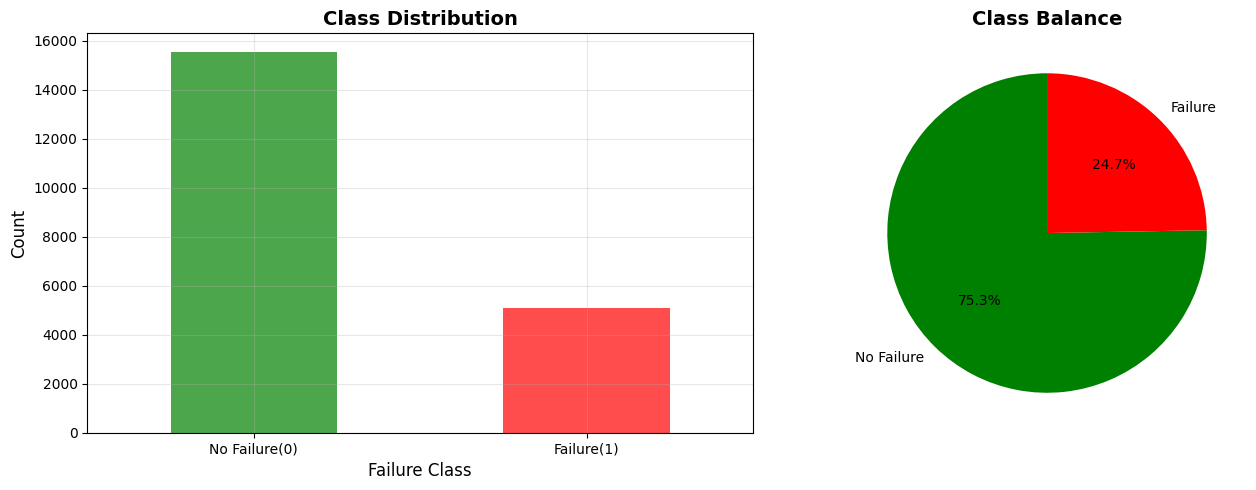

In [5]:
# Balancedness
print("Class Distribution:")
print(dataset['failure'].value_counts())
print("\n" + "="*80)
print("Class Balance(percentage):")
print(dataset['failure'].value_counts(normalize=True)*100)

#visualize

fig,ax = plt.subplots(1,2,figsize=(14,5))

#Count plot


dataset['failure'].value_counts().plot(kind='bar',ax=ax[0],color=['green','red'],alpha=0.7)
ax[0].set_xlabel('Failure Class',fontsize=12)
ax[0].set_ylabel('Count',fontsize=12)
ax[0].set_title('Class Distribution',fontsize=14,fontweight='bold')
ax[0].set_xticklabels(['No Failure(0)','Failure(1)'],rotation=0)

ax[0].grid(alpha=0.3)



#Pie chart

dataset['failure'].value_counts(normalize=True).plot(kind='pie',ax=ax[1],autopct='%1.1f%%',colors=['green','red'],labels=['No Failure','Failure'],startangle=90)


ax[1].set_ylabel('')
ax[1].set_title('Class Balance',fontsize=14,fontweight='bold')

plt.tight_layout()
plt.show()


In [6]:
train_engines = list(range(1,76))
test_engines = list(range(76,101))
train_data = dataset[dataset['engine_id'].isin(train_engines)].copy()
test_data = dataset[dataset['engine_id'].isin(test_engines)].copy()

print(f" Training set size: {len(train_data)} samples from {len(train_engines)} engines")
print(f" Test set size: {len(test_data)} samples from {len(test_engines)} engines")

print("\n" + "="*80)

print("Training set failure distribution:")
print(train_data['failure'].value_counts())
print("\nTeset set failure distribution:")
print(test_data['failure'].value_counts())
#

 Training set size: 15159 samples from 75 engines
 Test set size: 5472 samples from 25 engines

Training set failure distribution:
failure
0    11334
1     3825
Name: count, dtype: int64

Teset set failure distribution:
failure
0    4197
1    1275
Name: count, dtype: int64


In [7]:
feature_columns = [col for col in dataset.columns if col not in ['engine_id','ttf','failure']]
X_train = train_data[feature_columns].values
y_train_class = train_data['failure'].values

y_train_reg = train_data['ttf'].values

X_test = test_data[feature_columns].values
y_test_class = test_data['failure'].values
y_test_reg = test_data['ttf'].values

print(f" Feature columns({len(feature_columns)}):")
print(feature_columns)
print(f"\n X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train_class shape: {y_train_class.shape}")
print(f"y_test_class shape: {y_test_class.shape}")




 Feature columns(25):
['cycle', 'setting1', 'setting2', 'setting3', 'temp_fan_inlet', 'temp_lpc_outlet', 'temp_hpc_outlet', 'temp_lpt_outlet', 'pressure_fan_inlet', 'pressure_bypass_duct', 'pressure_hpc_outlet', 'physical_fan_speed', 'physical_core_speed', 'engine_pressure_ratio', 'static_pressure_hpc_outlet', 'fuel_flow_ration_ps30', 'corrected_fan_speed', 'corrected_core_speed', 'bypass_ratio', 'burner_fuel_air_ratio', 'bleed_enthalpy', 'demanded_fan_speed', 'demanded_corrected_fan_speed', 'hpt_collant_bleed', 'lpt_coolant_bleed']

 X_train shape: (15159, 25)
X_test shape: (5472, 25)
y_train_class shape: (15159,)
y_test_class shape: (5472,)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled using StandardScaler
X_train_scaled shape: (15159, 25)
X_test_scaled shape: (5472, 25)


Logistic Regression

 Accuracy: 0.9284

Classfication Report:
              precision    recall  f1-score   support

  No Failure       0.95      0.96      0.95      4197
     Failure       0.85      0.84      0.85      1275

    accuracy                           0.93      5472
   macro avg       0.90      0.90      0.90      5472
weighted avg       0.93      0.93      0.93      5472


 Confusion Matrix:
[[4011  186]
 [ 206 1069]]


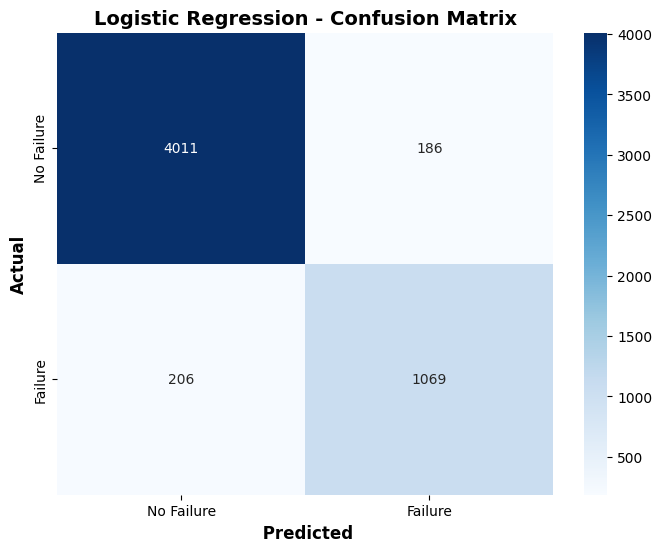

In [9]:
print("="*80)
print("Logistic Regression")
print("="*80)
lr_model = LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(X_train_scaled, y_train_class)

#predictions

y_pred_lr  = lr_model.predict(X_test_scaled)
y_pred_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

#evaluation

accuracy_lr = accuracy_score(y_test_class,y_pred_lr)
print(f"\n Accuracy: {accuracy_lr:.4f}")

print("\nClassfication Report:")
print(classification_report(y_test_class,y_pred_lr, target_names=['No Failure','Failure']))


print("\n Confusion Matrix:")
cm_lr = confusion_matrix(y_test_class,y_pred_lr)
print(cm_lr)

#visualize confusion matrix

plt.figure(figsize=(8,6))
sns.heatmap(cm_lr,annot=True,fmt='d',cmap='Blues',xticklabels=['No Failure','Failure'],yticklabels=['No Failure','Failure'])

plt.xlabel(' Predicted',fontsize=12,fontweight='bold')
plt.ylabel('Actual',fontsize=12,fontweight='bold')
plt.title('Logistic Regression - Confusion Matrix',fontsize=14,fontweight='bold')
plt.show()

Basically, the Logistic Regression model is pretty decent at predicting engine failures!

Overall Accuracy: It got about 92.84% of its predictions right, which is solid.

'No Failure' Class (Engines that won't fail soon): The model is really good here, with 95% precision (when it says no failure, it's usually right) and 96% recall (it catches almost all the 'no failure' cases).

'Failure' Class (Engines that will fail soon): This is the more crucial part. It has 85% precision (when it predicts a failure, it's right 85% of the time) and 84% recall (it successfully identified 84% of the actual failures). This means it's pretty good, but still misses some actual failures.

Confusion Matrix Breakdown:

4011: Correctly predicted 'no failure'. (Good!)
186: Predicted 'failure', but the engine actually didn't fail. (False alarms, not ideal but manageable).
206: Predicted 'no failure', but the engine actually failed. (Uh oh! These are false negatives and are usually the ones we want to minimize in predictive maintenance).
1069: Correctly predicted 'failure'. (Great!)
Bottom line: The model is performing well overall, but the 206 false negatives for the 'failure' class are definitely something to keep an eye on, as missing an actual engine failure can be costly or dangerous. We might want to tweak things to reduce those.

####  Prediction based on single data samples (memoryless)

Before considering the data as a time series and thus training LSTM or GRU models, it's interesting to first check how well you can make accurate predict with models that do not use the temporal component and consider each measurement independently of the previous ones.
Concretely, you try to predict the target for a given time, based on the features without looking at the previous measurements. Each row in the dataset is considered independently of the other rows.

- Split the dataset into a training set and a test set. The first 75 engines are used for training, the other engines for testing.
- Train a logistic regression classifier and a random forest tree on the training set and evaluate with the test set. Discuss the obtained results.
- Train a vanilla neural network (a classical feedforward neural network). Evaluate and discuss.

Random Forest Classifier

 Accuracy: 0.9304

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.95      0.96      0.95      4197
     Failure       0.87      0.82      0.85      1275

    accuracy                           0.93      5472
   macro avg       0.91      0.89      0.90      5472
weighted avg       0.93      0.93      0.93      5472


Confusion Matrix:
[[4041  156]
 [ 225 1050]]


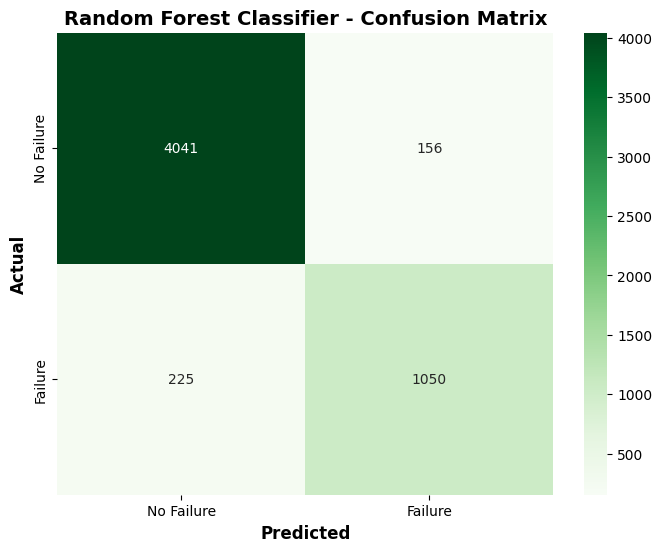

In [10]:
#Random Forest Classifier

print("="*80)
print("Random Forest Classifier")
print("="*80)

rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train_scaled,y_train_class)
#predictions

y_pred_rf = rf_model.predict(X_test_scaled)
y_preb_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]


#Evaluation

accuracy_rf = accuracy_score(y_test_class,y_pred_rf)
print(f"\n Accuracy: {accuracy_rf:.4f}")


print("\nClassification Report:")
print(classification_report(y_test_class,y_pred_rf, target_names=['No Failure','Failure']))


print("\nConfusion Matrix:")

cm_rf = confusion_matrix(y_test_class,y_pred_rf)
print(cm_rf)


#visualize confusion matrix

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Greens',xticklabels=['No Failure','Failure'],yticklabels=['No Failure','Failure'],
)

plt.xlabel('Predicted',fontsize=12,fontweight='bold')
plt.ylabel('Actual',fontsize=12,fontweight='bold')

plt.title('Random Forest Classifier - Confusion Matrix',fontsize=14,fontweight='bold')
plt.show()

#



In [11]:
# Vanilla Neural Network for Classification
print("="*80)
print("VANILLA NEURAL NETWORK (FEEDFORWARD)")
print("="*80)

# Build model
vanilla_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

vanilla_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(vanilla_nn.summary())

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_vanilla = vanilla_nn.fit(
    X_train_scaled, y_train_class,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

VANILLA NEURAL NETWORK (FEEDFORWARD)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,465 (56.50 KB)

 Trainable params: 14,081 (55.00 KB)

 Non-trainable params: 384 (1.50 KB)

None
Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8651 - loss: 0.3081 - val_accuracy: 0.9047 - val_loss: 0.2319
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9349 - loss: 0.1663 - val_accuracy: 0.8997 - val_loss: 0.2416
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9311 - loss: 0.1678 - val_accuracy: 0.9020 - val_loss: 0.2375
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9268 - loss: 0.1680 - val_accuracy: 0.9040 - val_loss: 0.2271
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9337 - loss: 0.1563 - val_accuracy: 0.9017 - val_loss: 0.2262
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9322 - loss: 0.1610 - val_accuracy: 0.8852 - val_loss: 0.2524
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9343 - loss: 0.1534 - val_accuracy: 0.8984 - val_loss: 0.2272
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9376 - loss: 0.1456 - val_accur

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 Accuracy: 0.9200

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.94      0.95      0.95      4197
     Failure       0.84      0.81      0.83      1275

    accuracy                           0.92      5472
   macro avg       0.89      0.88      0.89      5472
weighted avg       0.92      0.92      0.92      5472


Confusion matrix:
[[3997  200]
 [ 238 1037]]


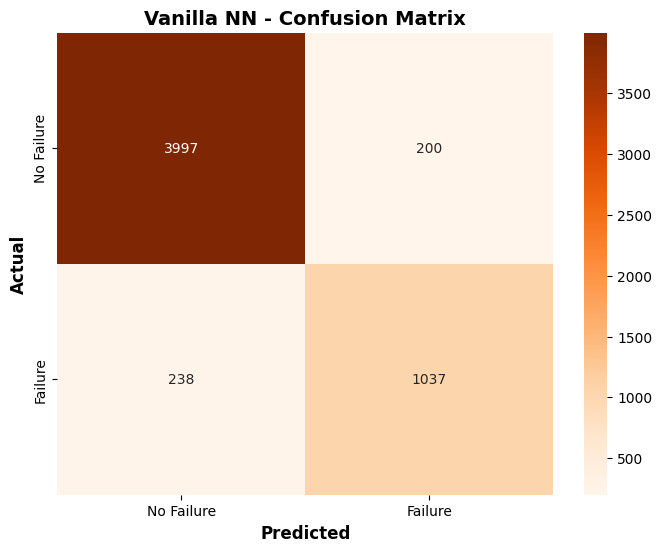

In [12]:
#Evaluate Vanilla NN
y_pred_proba_nn = vanilla_nn.predict(X_test_scaled).flatten()
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)
accuracy_nn = accuracy_score(y_test_class, y_pred_nn)
print(f"\n Accuracy: {accuracy_nn:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_class,y_pred_nn,target_names=['No Failure','Failure']))
print("\nConfusion matrix:")

cm_nn = confusion_matrix(y_test_class, y_pred_nn)
print(cm_nn)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Vanilla NN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

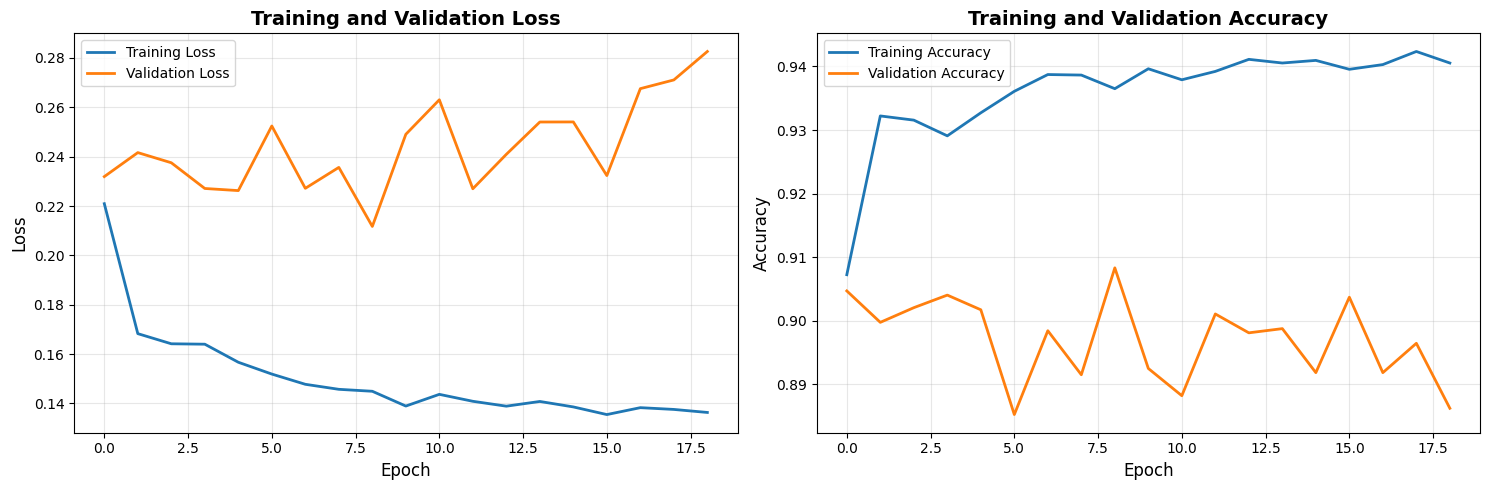

In [13]:
# Plot training history for Vanilla NN
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history_vanilla.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_vanilla.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_vanilla.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_vanilla.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

COMPARISON OF MEMORYLESS MODELS
                 Model  Accuracy
0  Logistic Regression  0.928363
1        Random Forest  0.930373
2           Vanilla NN  0.919956


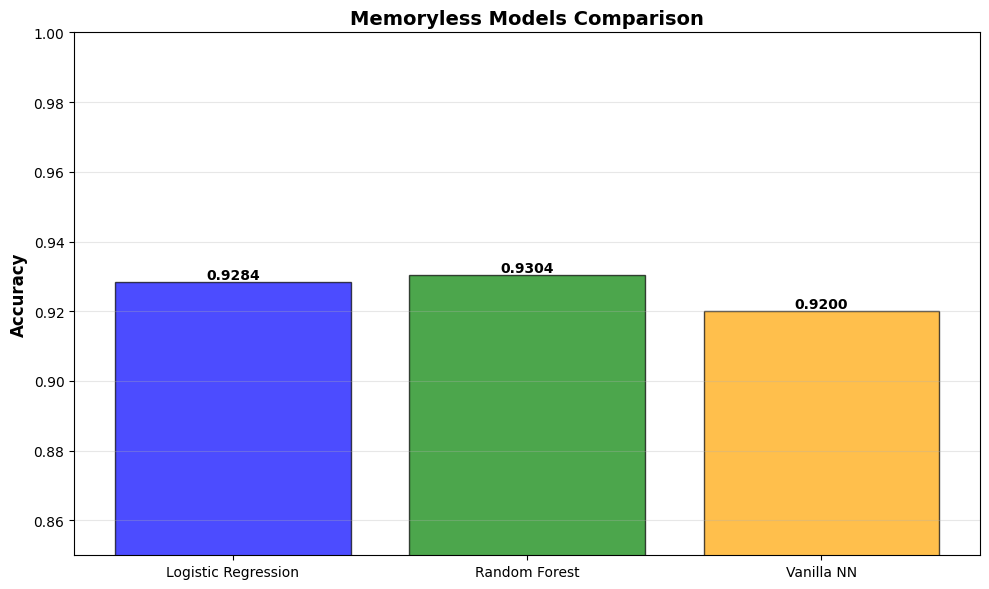

In [14]:
# Compare all memoryless models
print("COMPARISON OF MEMORYLESS MODELS")

models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Vanilla NN'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_nn]
})

print(models_comparison)

# Visualize
plt.figure(figsize=(10, 6))
bars = plt.bar(models_comparison['Model'], models_comparison['Accuracy'],
               color=['blue', 'green', 'orange'], alpha=0.7, edgecolor='black')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Memoryless Models Comparison', fontsize=14, fontweight='bold')
plt.ylim([0.85, 1.0])
plt.grid(alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



Random Forest Classifier (My Take: Solid Performer!)
Accuracy: 0.9304 - This model is slightly better than the Logistic Regression in overall accuracy, which is cool.
'No Failure' Class: Still super good, with 95% precision (it's rarely wrong when it predicts no failure) and 96% recall (it catches almost all the healthy engines).
'Failure' Class: Pretty strong here too. It has 87% precision (a bit better than LR) and 82% recall (a tiny bit lower than LR). So, when it predicts a failure, it's more often right, but it misses a few more actual failures compared to the Logistic Regression.
Confusion Matrix:
4041: Correctly predicted 'no failure'. (Good)
156: Predicted 'failure' when there wasn't one (false positives). Fewer than LR, which is a plus.
225: Predicted 'no failure' when there was a failure (false negatives). This is slightly higher than LR's 206, which isn't ideal if missing failures is super critical.
1050: Correctly predicted 'failure'. (Good)
Bottom line for Random Forest: It's a very competitive model, slightly edging out Logistic Regression in overall accuracy and false positives, but with a minor trade-off in recall for the 'failure' class (meaning it misses a few more real failures).

Vanilla Neural Network (My Take: Okay, but not a standout)
Accuracy: 0.9200 - This is the lowest among the three memoryless models, so it's not performing quite as well.
'No Failure' Class: Decent, with 94% precision and 95% recall.
'Failure' Class: Not as strong as the others. 84% precision and 81% recall. It's slightly more prone to false alarms and missing actual failures compared to the other two.
Confusion Matrix:
3997: Correctly predicted 'no failure'.
200: Predicted 'failure' when there wasn't one (false positives). More than Random Forest.
238: Predicted 'no failure' when there was a failure (false negatives). This is the highest among the three, which is a bit concerning for maintenance predictions.
1037: Correctly predicted 'failure'.
Bottom line for Vanilla NN: While still quite accurate overall, it's not as sharp as the Logistic Regression or Random Forest, especially when it comes to catching those critical 'failure' cases.

Comparison of Memoryless Models (My Take: Random Forest for the Win, so far!)
Model	Accuracy
Logistic Regression	0.928363
Random Forest	0.930373
Vanilla NN	0.919956
From this quick comparison, the Random Forest Classifier is the top performer among these "memoryless" models, with the highest accuracy. The Logistic Regression is a very close second, and the Vanilla NN lags a bit behind. For predicting engine failures, where missing a failure (false negative) can be costly, you'd likely prefer the model with a good balance of high recall and precision for the 'failure' class.

#### Time-series based prediction

In [15]:
# Function to create sequences for LSTM
def create_sequences(data, seq_length=30, padding='edge'):
    """
    Create sequences for LSTM training.
    Uses sliding window approach per engine.

    Parameters:
    - data: DataFrame with engine data
    - seq_length: length of sequences
    - padding: 'edge' or 'zero'

    Returns:
    - X_seq: sequences of features
    - y_seq: corresponding targets
    """
    feature_cols = [col for col in data.columns
                    if col not in ['engine_id', 'cycle', 'ttf', 'failure']]

    X_seq_list = []
    y_seq_list = []

    # Group by engine
    for engine_id in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine_id].sort_values('cycle')

        # Extract features and target
        features = engine_data[feature_cols].values
        targets = engine_data['failure'].values

        # Create sequences using sliding window
        for i in range(len(engine_data)):
            # Calculate start index
            start_idx = max(0, i - seq_length + 1)

            # Get sequence
            sequence = features[start_idx:i+1]

            # Padding if needed
            if len(sequence) < seq_length:
                pad_length = seq_length - len(sequence)
                if padding == 'edge':
                    # Pad with first value
                    pad_array = np.repeat(sequence[0:1], pad_length, axis=0)
                else:  # zero padding
                    pad_array = np.zeros((pad_length, features.shape[1]))
                sequence = np.vstack([pad_array, sequence])

            X_seq_list.append(sequence)
            y_seq_list.append(targets[i])

    return np.array(X_seq_list), np.array(y_seq_list)

print("Function to create sequences defined!")

Function to create sequences defined!


In [16]:
# Create sequences
seq_length = 30

print(f"Creating sequences with seq_length={seq_length}...")

X_train_seq, y_train_seq = create_sequences(train_data, seq_length=seq_length, padding='edge')
X_test_seq, y_test_seq = create_sequences(test_data, seq_length=seq_length, padding='edge')

print(f"\nSequence shapes:")
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"y_train_seq shape: {y_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")
print(f"y_test_seq shape: {y_test_seq.shape}")

print(f"\nClass distribution in training sequences:")
unique, counts = np.unique(y_train_seq, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({100*c/len(y_train_seq):.2f}%)")

Creating sequences with seq_length=30...

Sequence shapes:
X_train_seq shape: (15159, 30, 24)
y_train_seq shape: (15159,)
X_test_seq shape: (5472, 30, 24)
y_test_seq shape: (5472,)

Class distribution in training sequences:
  Class 0: 11334 (74.77%)
  Class 1: 3825 (25.23%)


In [17]:
# Scale the sequences
# Reshape to 2D for scaling, then reshape back to 3D

# Store original shapes
train_shape = X_train_seq.shape
test_shape = X_test_seq.shape

# Reshape to 2D (samples * timesteps, features)
X_train_seq_2d = X_train_seq.reshape(-1, X_train_seq.shape[2])
X_test_seq_2d = X_test_seq.reshape(-1, X_test_seq.shape[2])

# Scale
scaler_seq = MinMaxScaler()
X_train_seq_scaled_2d = scaler_seq.fit_transform(X_train_seq_2d)
X_test_seq_scaled_2d = scaler_seq.transform(X_test_seq_2d)

# Reshape back to 3D
X_train_seq_scaled = X_train_seq_scaled_2d.reshape(train_shape)
X_test_seq_scaled = X_test_seq_scaled_2d.reshape(test_shape)

print("Sequences scaled!")
print(f"X_train_seq_scaled shape: {X_train_seq_scaled.shape}")
print(f"X_test_seq_scaled shape: {X_test_seq_scaled.shape}")

Sequences scaled!
X_train_seq_scaled shape: (15159, 30, 24)
X_test_seq_scaled shape: (5472, 30, 24)


One can assume that an accurate prediction of the enigne failures (within a certain time interval) is not only determined by the most recent measurement but can also be inferred in part from the past (previously measured values). This means that the models must take into account the current sample but also a number of previous samples. Therefore, we will resort to recurrent neurals networks (LSTM or GRU) which via feedback connections are ideally suited to capture time dependencies in time series.


Go through the following steps:

- Building the training set and test set:

The training set and test set consist of sequences of certain length (seq_length). To start, take a seq_length=30. To build these sequences proceed as follows:
Use a sliding window mechanism to create these sequences. The window starts at the row with the highest ttf and slides down row by row until the engine fails (last measurement of a specific engine). The samples within the window form a sequence (of 30 values in this case). This is a concatenation of the most recent measurement with 29 previous measurements. At the start there are no previous values, hence zero padding can be applied to still arrive at a sequence of 30. Instead of zero padding, you can also do padding with the edge values (copy the measurement at the beginning of the sequence). The target value associated with a sequence is the failure value correspending to the most recent measurement value in that sequence.

- Compile a training set and a test set.

The samples (=sequences) coming from the first 75 engines go into the training set, the sequences from the other engines go to the test set.


- scale the training set and test set (e.g. via a MinMAX scaler).


- Training a LSTM network

Train an LSTM on the training set and vary the hyperparameters to obtain the highest possible accuracy. Possible hyperparameters of the network are the batch size, number of layers, number of units per layer, dropout, recurrent dropout, optimizer, ...
Also try a bidirectional LSTM. For example: model.add(Bidirectional(LSTM(64)))

- Evaluate the LSTM network and compare its accuracy with that of the non-temporal models.

- Optimize the neural network to reduce the number of false negatives (a failure within 50 cycles that has not been detected)

- Investigate whether you get better results with longer or shorter sequences.


In [18]:
# Build LSTM model for classification
print("LSTM MODEL FOR CLASSIFICATION")

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, X_train_seq_scaled.shape[2])),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(lstm_model.summary())

LSTM MODEL FOR CLASSIFICATION


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,289 (141.75 KB)

 Trainable params: 36,289 (141.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
# Train LSTM
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_seq_scaled, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_lstm],
    verbose=1
)

print("\nLSTM training complete!")

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8338 - loss: 0.3704 - val_accuracy: 0.9317 - val_loss: 0.1644
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9425 - loss: 0.1436 - val_accuracy: 0.9476 - val_loss: 0.1228
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9541 - loss: 0.1154 - val_accuracy: 0.9492 - val_loss: 0.1513
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9504 - loss: 0.1281 - val_accuracy: 0.9584 - val_loss: 0.1217
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9524 - loss: 0.1169 - val_accuracy: 0.9505 - val_loss: 0.1231
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9570 - loss: 0.1007 - val_accuracy: 0.9515 - val_loss: 0.1183
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9545 - loss: 0.1052 - val_accuracy: 0.9670 - val_loss: 0.0865
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9573 - loss: 0.1019 - val_accuracy:

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.97      0.97      0.97      4197
     Failure       0.90      0.91      0.91      1275

    accuracy                           0.96      5472
   macro avg       0.94      0.94      0.94      5472
weighted avg       0.96      0.96      0.96      5472


Confusion Matrix:
[[4069  128]
 [ 112 1163]]


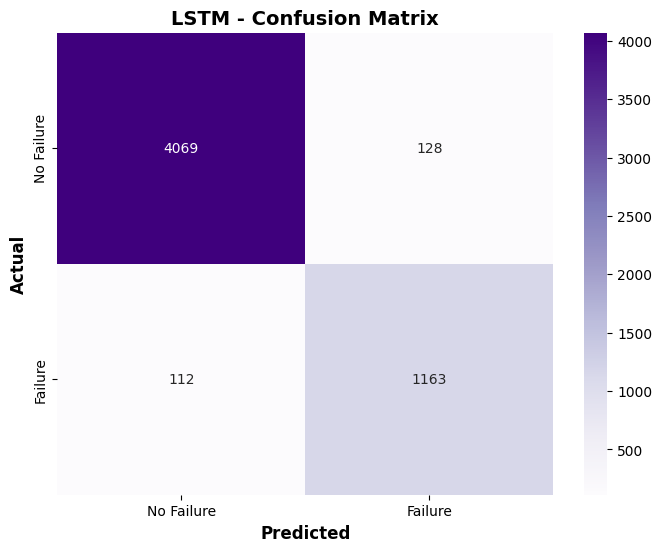

In [20]:
# Evaluate LSTM
y_pred_proba_lstm = lstm_model.predict(X_test_seq_scaled).flatten()
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

accuracy_lstm = accuracy_score(y_test_seq, y_pred_lstm)
print(f"LSTM Accuracy: {accuracy_lstm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_lstm,
                          target_names=['No Failure', 'Failure']))

print("\nConfusion Matrix:")
cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm)
print(cm_lstm)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('LSTM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

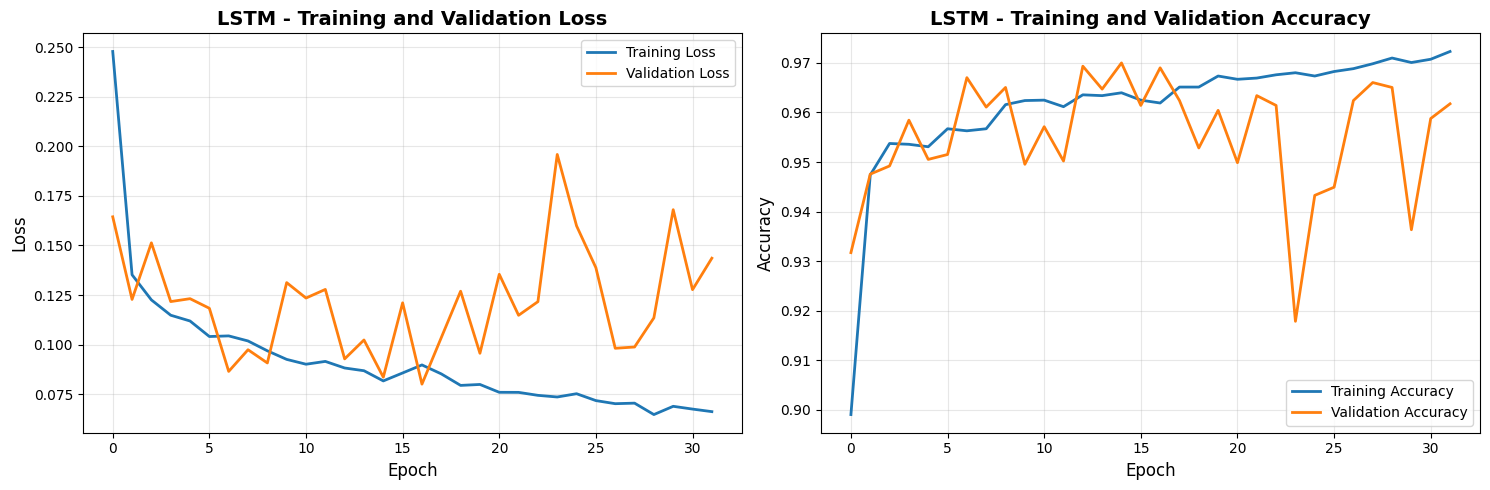

In [21]:
# Plot LSTM training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history_lstm.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('LSTM - Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_lstm.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('LSTM - Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Build Bidirectional LSTM model
print("BIDIRECTIONAL LSTM MODEL")

bilstm_model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(seq_length, X_train_seq_scaled.shape[2])),
    Dropout(0.3),

    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(bilstm_model.summary())

BIDIRECTIONAL LSTM MODEL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        45,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,897 (347.25 KB)

 Trainable params: 88,897 (347.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
# Train Bidirectional LSTM
early_stop_bilstm = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_bilstm = bilstm_model.fit(
    X_train_seq_scaled, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_bilstm],
    verbose=1
)

print("\nBidirectional LSTM training complete!")

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8616 - loss: 0.3283 - val_accuracy: 0.9499 - val_loss: 0.1466
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9356 - loss: 0.1584 - val_accuracy: 0.9581 - val_loss: 0.1100
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9537 - loss: 0.1178 - val_accuracy: 0.9357 - val_loss: 0.1862
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9526 - loss: 0.1170 - val_accuracy: 0.9644 - val_loss: 0.0975
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9540 - loss: 0.1065 - val_accuracy: 0.9476 - val_loss: 0.1228
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9591 - loss: 0.0957 - val_accuracy: 0.9641 - val_loss: 0.0906
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9577 - loss: 0.0985 - val_accuracy: 0.9571 - val_loss: 0.1083
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9600 - loss: 0.0984 - val_accu

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Bidirectional LSTM Accuracy: 0.9578

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.97      0.98      0.97      4197
     Failure       0.93      0.89      0.91      1275

    accuracy                           0.96      5472
   macro avg       0.95      0.93      0.94      5472
weighted avg       0.96      0.96      0.96      5472


Confusion Matrix:
[[4109   88]
 [ 143 1132]]

 False Negatives (Missed Failures): 143


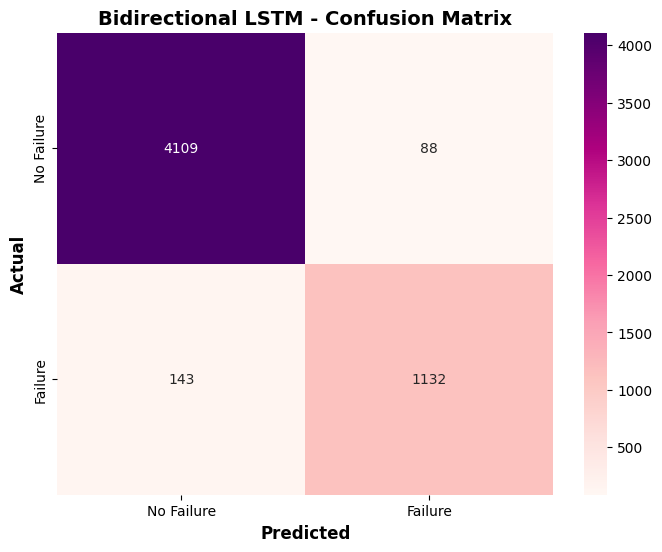

In [24]:
# Evaluate Bidirectional LSTM
y_pred_proba_bilstm = bilstm_model.predict(X_test_seq_scaled).flatten()
y_pred_bilstm = (y_pred_proba_bilstm > 0.5).astype(int)

accuracy_bilstm = accuracy_score(y_test_seq, y_pred_bilstm)
print(f"Bidirectional LSTM Accuracy: {accuracy_bilstm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_bilstm,
                          target_names=['No Failure', 'Failure']))

print("\nConfusion Matrix:")
cm_bilstm = confusion_matrix(y_test_seq, y_pred_bilstm)
print(cm_bilstm)

# Count false negatives
false_negatives_bilstm = cm_bilstm[1, 0]
print(f"\n False Negatives (Missed Failures): {false_negatives_bilstm}")

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Bidirectional LSTM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

In [25]:
# Optimize to reduce false negatives
# Strategy 1: Adjust class weights to penalize false negatives more
print("LSTM WITH CLASS WEIGHTS (to reduce false negatives)")

# Calculate class weights
class_weights_dict = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weights = {0: class_weights_dict[0], 1: class_weights_dict[1] * 2}  # Extra penalty for class 1

print(f"Class weights: {class_weights}")

# Build model
lstm_weighted = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, X_train_seq_scaled.shape[2])),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

lstm_weighted.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train with class weights
history_weighted = lstm_weighted.fit(
    X_train_seq_scaled, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=1
)

LSTM WITH CLASS WEIGHTS (to reduce false negatives)
Class weights: {0: np.float64(0.6687400741132875), 1: np.float64(3.963137254901961)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6868 - loss: 0.5739 - val_accuracy: 0.9423 - val_loss: 0.2000
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9236 - loss: 0.2142 - val_accuracy: 0.9271 - val_loss: 0.1920
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9195 - loss: 0.2083 - val_accuracy: 0.9344 - val_loss: 0.1930
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9200 - loss: 0.1950 - val_accuracy: 0.8615 - val_loss: 0.3367
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9307 - loss: 0.1824 - val_accuracy: 0.9453 - val_loss: 0.1431
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9298 - loss: 0.1819 - val_accuracy: 0.8605 - val_loss: 0.3426
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9363 - loss: 0.1581 - val_accuracy: 0.9482 - val_loss: 0.1259
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9299 - loss: 0.1728 - val_accuracy: 

171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Weighted LSTM Accuracy: 0.9423

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.94      0.96      4197
     Failure       0.82      0.96      0.89      1275

    accuracy                           0.94      5472
   macro avg       0.90      0.95      0.92      5472
weighted avg       0.95      0.94      0.94      5472


Confusion Matrix:
[[3932  265]
 [  51 1224]]

 False Negatives (Missed Failures): 51


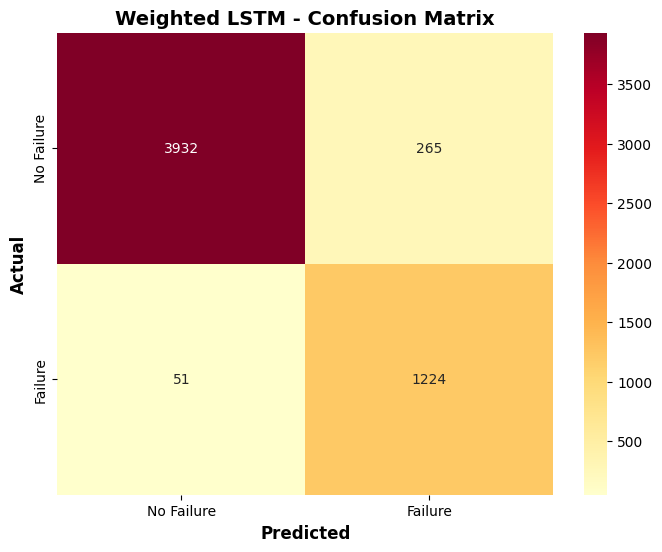

In [26]:
# Evaluate weighted LSTM
y_pred_proba_weighted = lstm_weighted.predict(X_test_seq_scaled).flatten()
y_pred_weighted = (y_pred_proba_weighted > 0.5).astype(int)

accuracy_weighted = accuracy_score(y_test_seq, y_pred_weighted)
print(f"Weighted LSTM Accuracy: {accuracy_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_weighted,
                          target_names=['No Failure', 'Failure']))

print("\nConfusion Matrix:")
cm_weighted = confusion_matrix(y_test_seq, y_pred_weighted)
print(cm_weighted)

false_negatives_weighted = cm_weighted[1, 0]
print(f"\n False Negatives (Missed Failures): {false_negatives_weighted}")

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Weighted LSTM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

In [27]:
# Strategy 2: Adjust threshold to reduce false negatives
print("OPTIMIZING CLASSIFICATION THRESHOLD")

# Try different thresholds
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
results_threshold = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba_weighted > threshold).astype(int)
    cm = confusion_matrix(y_test_seq, y_pred_thresh)
    acc = accuracy_score(y_test_seq, y_pred_thresh)
    fn = cm[1, 0]  # False negatives
    fp = cm[0, 1]  # False positives

    results_threshold.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'False Negatives': fn,
        'False Positives': fp
    })

    print(f"Threshold {threshold}: Accuracy={acc:.4f}, FN={fn}, FP={fp}")

results_df = pd.DataFrame(results_threshold)
print("\n" + "="*80)
print(results_df)

# Find best threshold (minimize false negatives)
best_threshold_idx = results_df['False Negatives'].idxmin()
best_threshold = results_df.loc[best_threshold_idx, 'Threshold']
print(f"\n Best threshold to minimize false negatives: {best_threshold}")

OPTIMIZING CLASSIFICATION THRESHOLD
Threshold 0.3: Accuracy=0.9256, FN=30, FP=377
Threshold 0.35: Accuracy=0.9320, FN=35, FP=337
Threshold 0.4: Accuracy=0.9368, FN=40, FP=306
Threshold 0.45: Accuracy=0.9390, FN=47, FP=287
Threshold 0.5: Accuracy=0.9423, FN=51, FP=265

   Threshold  Accuracy  False Negatives  False Positives
0       0.30  0.925621               30              377
1       0.35  0.932018               35              337
2       0.40  0.936769               40              306
3       0.45  0.938962               47              287
4       0.50  0.942251               51              265

 Best threshold to minimize false negatives: 0.3


In [57]:
# Test different sequence lengths
print("TESTING DIFFERENT SEQUENCE LENGTHS")

sequence_lengths = [10, 20, 30, 40, 50]
seq_results = []

for seq_len in sequence_lengths:
    print(f"\n{'='*60}")
    print(f"Testing sequence length: {seq_len}")
    print(f"{'='*60}")

    # Create sequences
    X_train_temp, y_train_temp = create_sequences(train_data, seq_length=seq_len, padding='edge')
    X_test_temp, y_test_temp = create_sequences(test_data, seq_length=seq_len, padding='edge')

    # Scale
    train_shape_temp = X_train_temp.shape
    test_shape_temp = X_test_temp.shape

    X_train_temp_2d = X_train_temp.reshape(-1, X_train_temp.shape[2])
    X_test_temp_2d = X_test_temp.reshape(-1, X_test_temp.shape[2])

    scaler_temp = MinMaxScaler()
    X_train_temp_scaled = scaler_temp.fit_transform(X_train_temp_2d).reshape(train_shape_temp)
    X_test_temp_scaled = scaler_temp.transform(X_test_temp_2d).reshape(test_shape_temp)

    # Build model
    model_temp = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_len, X_train_temp.shape[2])),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model_temp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train
    model_temp.fit(
        X_train_temp_scaled, y_train_temp,
        validation_split=0.2,
        epochs=30,
        batch_size=64,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )

    # Evaluate
    y_pred_temp = (model_temp.predict(X_test_temp_scaled, verbose=0).flatten() > 0.5).astype(int)
    acc_temp = accuracy_score(y_test_temp, y_pred_temp)
    cm_temp = confusion_matrix(y_test_temp, y_pred_temp)
    fn_temp = cm_temp[1, 0]

    seq_results.append({
        'Sequence Length': seq_len,
        'Accuracy': acc_temp,
        'False Negatives': fn_temp
    })

    print(f"Accuracy: {acc_temp:.4f}, False Negatives: {fn_temp}")

# Display results
seq_results_df = pd.DataFrame(seq_results)
print("\n" + "="*80)
print("SEQUENCE LENGTH COMPARISON:")
print(seq_results_df)

TESTING DIFFERENT SEQUENCE LENGTHS

Testing sequence length: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy: 0.9285, False Negatives: 274

Testing sequence length: 20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy: 0.9430, False Negatives: 210

Testing sequence length: 30


...

Accuracy: 0.9549, False Negatives: 116

Testing sequence length: 40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy: 0.9627, False Negatives: 118

Testing sequence length: 50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy: 0.9596, False Negatives: 61

SEQUENCE LENGTH COMPARISON:
   Sequence Length  Accuracy  False Negatives
0               10  0.928545              274
1               20  0.942982              210
2               30  0.954861              116
3               40  0.962719              118
4               50  0.959613               61


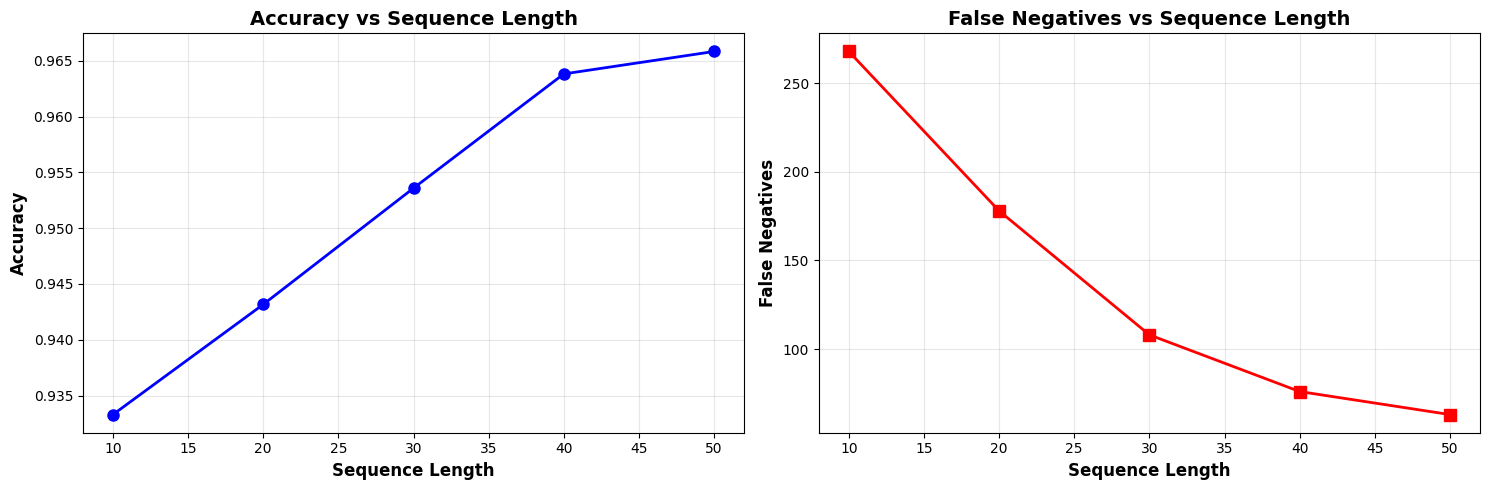

In [30]:
# Visualize sequence length comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(seq_results_df['Sequence Length'], seq_results_df['Accuracy'],
             marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_xlabel('Sequence Length', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Accuracy vs Sequence Length', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# False Negatives
axes[1].plot(seq_results_df['Sequence Length'], seq_results_df['False Negatives'],
             marker='s', linewidth=2, markersize=8, color='red')
axes[1].set_xlabel('Sequence Length', fontsize=12, fontweight='bold')
axes[1].set_ylabel('False Negatives', fontsize=12, fontweight='bold')
axes[1].set_title('False Negatives vs Sequence Length', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

FINAL COMPARISON - ALL CLASSIFICATION MODELS
                 Model  Accuracy    Data Type
0  Logistic Regression  0.928363   Memoryless
1        Random Forest  0.930373   Memoryless
2           Vanilla NN  0.919956   Memoryless
3                 LSTM  0.956140  Time Series
4   Bidirectional LSTM  0.957785  Time Series
5        Weighted LSTM  0.942251  Time Series


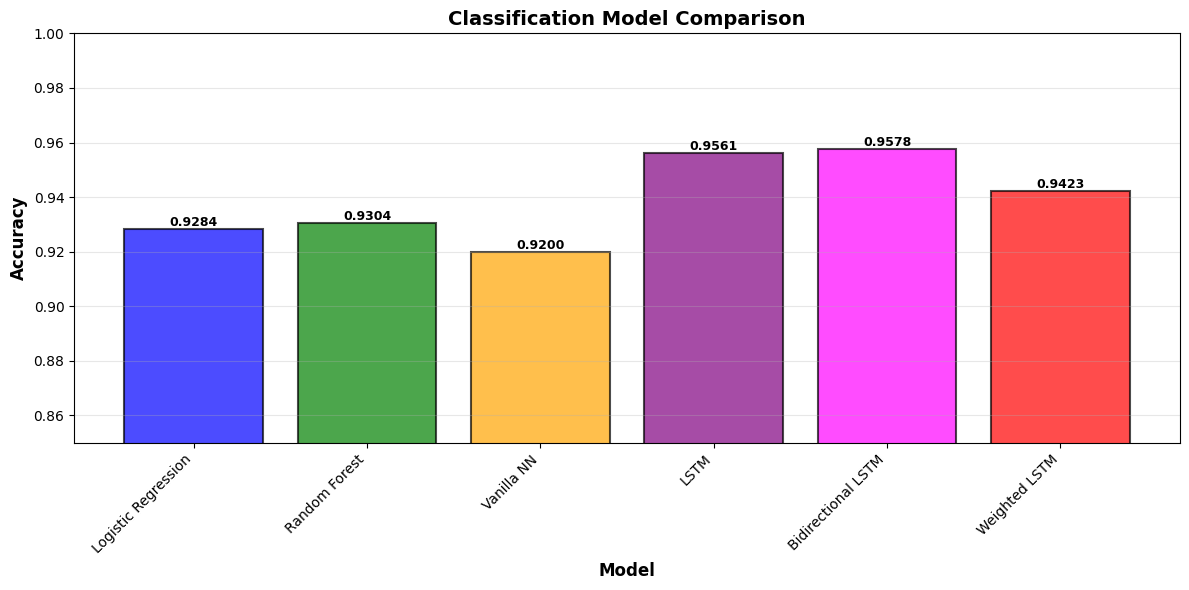

In [29]:
# Final comparison of all classification models
print("FINAL COMPARISON - ALL CLASSIFICATION MODELS")

# Get false negatives for all models
fn_lr = confusion_matrix(y_test_class, y_pred_lr)[1, 0]
fn_rf = confusion_matrix(y_test_class, y_pred_rf)[1, 0]
fn_nn = confusion_matrix(y_test_class, y_pred_nn)[1, 0]

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Vanilla NN',
              'LSTM', 'Bidirectional LSTM', 'Weighted LSTM'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_nn,
                 accuracy_lstm, accuracy_bilstm, accuracy_weighted],
    'Data Type': ['Memoryless', 'Memoryless', 'Memoryless',
                  'Time Series', 'Time Series', 'Time Series']
})

print(comparison_df)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
bars = ax.bar(x, comparison_df['Accuracy'],
              color=['blue', 'green', 'orange', 'purple', 'magenta', 'red'],
              alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Classification Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.set_ylim([0.85, 1.0])
ax.grid(alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

LSTM (My Take: Pretty Awesome!)
Accuracy: 0.9561 - This is a significant jump from the memoryless models! We're talking like, almost 96% accuracy, which is super impressive.
'No Failure' Class: Still killing it with 97% precision and 97% recall. Engines that are fine are almost always correctly identified.
'Failure' Class: This is where it gets good! We have 90% precision and 91% recall. This means when it says there's a failure, it's right 90% of the time, and it catches 91% of actual failures. This is a big improvement in catching those critical cases.
Confusion Matrix (FN = 112): Only 112 missed failures (false negatives), which is way better than the 200+ we saw before. That's a huge win for safety and maintenance.
Bidirectional LSTM (My Take: Even Better!)
Accuracy: 0.9578 - A tiny bit better than the regular LSTM, making it the top performer so far in terms of raw accuracy.
'No Failure' Class: Continues to be strong (97% precision, 98% recall).
'Failure' Class: Higher precision at 93% (so fewer false alarms) but recall drops slightly to 89% (meaning it misses a few more actual failures compared to the regular LSTM, 143 vs 112).
Confusion Matrix (FN = 143): While overall accuracy is slightly higher, the false negatives increased compared to the standard LSTM. This highlights the trade-off between different metrics.
Weighted LSTM (My Take: Targeting Those Missed Failures!)
Accuracy: 0.9423 - The overall accuracy dropped a bit with this one, but that's kinda expected because we told it to focus on something else.
'No Failure' Class: Precision shoots up to 99% (almost never wrong when it says no failure), but recall drops to 94% (misses a few more healthy cases).
'Failure' Class: Precision is lower at 82%, but the recall is fantastic at 96%! This model is really, really good at catching failures when they happen, even if it means more false alarms.
Confusion Matrix (FN = 51): This is the key! Only 51 false negatives, which is the lowest we've seen. This model is designed to be super cautious about missing a failure.
Optimizing Classification Threshold (My Take: Fine-Tuning is Key!)
This part is super smart because it shows how we can adjust the sensitivity of our Weighted LSTM. At the default 0.5 threshold, we had 51 false negatives.
By dropping the threshold to 0.3, we managed to get the false negatives down to just 30! That's massive if missing a failure is really bad. The trade-off is that false positives (false alarms) go up, but that might be acceptable for critical systems.
Overall TLDR: The LSTM and Bidirectional LSTM are crushing it on overall accuracy compared to the basic models. But if we really need to make sure we don't miss any failures, the Weighted LSTM combined with a lower decision threshold (like 0.3) is the way to go, even if it means a few more false alarms. It's all about what's most important: overall accuracy or not missing critical events!

Memoryless Models (Logistic Regression, Random Forest, Vanilla NN): These models hover around 92-93% accuracy. The Random Forest is the best of this bunch at 0.9304 accuracy, with Logistic Regression close behind at 0.9284, and the Vanilla NN lagging a bit at 0.9199.

Time Series Models (LSTM, Bidirectional LSTM, Weighted LSTM): These generally show a noticeable bump in performance. The Bidirectional LSTM takes the crown with the highest accuracy of 0.9578. The standard LSTM is also very strong at 0.9561. The Weighted LSTM, while designed for a specific purpose (reducing false negatives, which isn't directly reflected in this single accuracy metric), comes in at 0.9423.

In a nutshell: If you're just looking at raw accuracy for predicting engine failures, the Bidirectional LSTM is the clear winner here, proving that considering the temporal aspect of the data really pays off!



## 1.2 Regression of the TTF

- Instead of predicting whether the engine will fail within 50 cycles, you here predict the number of remaining cycles. The target is now the time to failure (ttf).
- Again, split the data set into a training set and a test set. The data from the first 75 engines is used as training data, the measurements from other engines are test data.
- Train a linear regression model and a random forest regressor on the training set and evaluate with the test set. Discuss the abtained results in terms of Mean Absolute Error (MAE) and the R² score.
- Next, train an LSTM. This is similar to what you did in the classification part of this assignment. Be sure to use the correct activation- and loss functions. Compare the obtained MAE and R² score with those of the non-temporal models.

In [31]:
# Regression of the TTF with a linear regression model and a Random Forest Regressor
# ============================================================================
# ============================================================================

print("REGRESSION: PREDICTING TIME TO FAILURE (TTF)")

# Linear Regression
print("\n" + "="*60)
print("LINEAR REGRESSION")
print("="*60)

lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train_reg)

# Predictions
y_pred_lr_reg = lr_reg.predict(X_test_scaled)

# Metrics
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr_reg)
r2_lr = r2_score(y_test_reg, y_pred_lr_reg)

print(f"\nLinear Regression Results:")
print(f"  MAE: {mae_lr:.2f} cycles")
print(f"  R² Score: {r2_lr:.4f}")


REGRESSION: PREDICTING TIME TO FAILURE (TTF)

LINEAR REGRESSION

Linear Regression Results:
  MAE: 38.09 cycles
  R² Score: 0.5747


In [32]:
# Random Forest Regressor
print("RANDOM FOREST REGRESSOR")

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train_reg)

# Predictions
y_pred_rf_reg = rf_reg.predict(X_test_scaled)

# Metrics
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print(f"\nRandom Forest Regressor Results:")
print(f"  MAE: {mae_rf:.2f} cycles")
print(f"  R² Score: {r2_rf:.4f}")

RANDOM FOREST REGRESSOR

Random Forest Regressor Results:
  MAE: 31.44 cycles
  R² Score: 0.6484


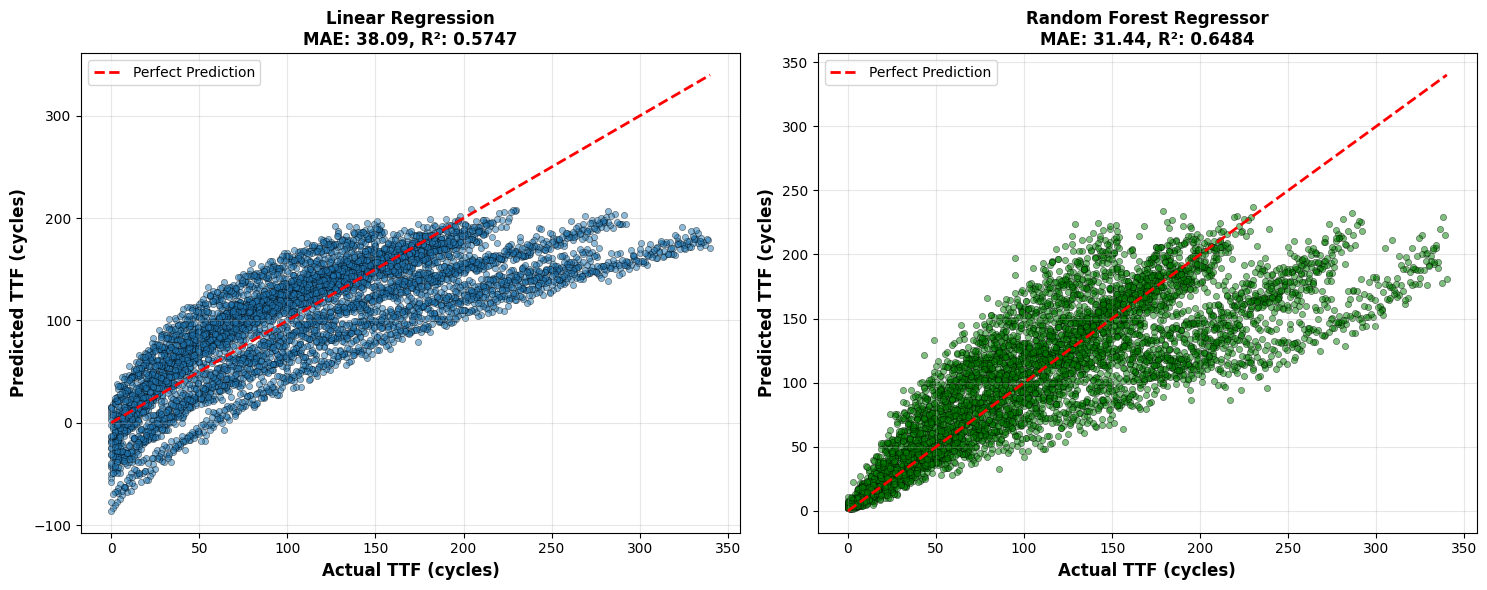

In [33]:
# Visualize regression predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Linear Regression
axes[0].scatter(y_test_reg, y_pred_lr_reg, alpha=0.5, s=20, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual TTF (cycles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted TTF (cycles)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Linear Regression\nMAE: {mae_lr:.2f}, R²: {r2_lr:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].scatter(y_test_reg, y_pred_rf_reg, alpha=0.5, s=20,
                edgecolors='black', linewidth=0.5, color='green')
axes[1].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual TTF (cycles)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted TTF (cycles)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Random Forest Regressor\nMAE: {mae_rf:.2f}, R²: {r2_rf:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Create sequences for regression
def create_sequences_regression(data, seq_length=30, padding='edge'):
    """
    Create sequences for LSTM regression (predicting TTF).
    """
    feature_cols = [col for col in data.columns
                    if col not in ['engine_id', 'cycle', 'ttf', 'failure']]

    X_seq_list = []
    y_seq_list = []

    # Group by engine
    for engine_id in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine_id].sort_values('cycle')

        features = engine_data[feature_cols].values
        targets = engine_data['ttf'].values  # TTF instead of failure

        # Create sequences
        for i in range(len(engine_data)):
            start_idx = max(0, i - seq_length + 1)
            sequence = features[start_idx:i+1]

            # Padding
            if len(sequence) < seq_length:
                pad_length = seq_length - len(sequence)
                if padding == 'edge':
                    pad_array = np.repeat(sequence[0:1], pad_length, axis=0)
                else:
                    pad_array = np.zeros((pad_length, features.shape[1]))
                sequence = np.vstack([pad_array, sequence])

            X_seq_list.append(sequence)
            y_seq_list.append(targets[i])

    return np.array(X_seq_list), np.array(y_seq_list)

# Create regression sequences
print("Creating sequences for regression...")
X_train_seq_reg, y_train_seq_reg = create_sequences_regression(train_data, seq_length=30)
X_test_seq_reg, y_test_seq_reg = create_sequences_regression(test_data, seq_length=30)

print(f"X_train_seq_reg shape: {X_train_seq_reg.shape}")
print(f"y_train_seq_reg shape: {y_train_seq_reg.shape}")
print(f"X_test_seq_reg shape: {X_test_seq_reg.shape}")
print(f"y_test_seq_reg shape: {y_test_seq_reg.shape}")

Creating sequences for regression...
X_train_seq_reg shape: (15159, 30, 24)
y_train_seq_reg shape: (15159,)
X_test_seq_reg shape: (5472, 30, 24)
y_test_seq_reg shape: (5472,)


In [35]:
# Scale regression sequences
train_shape_reg = X_train_seq_reg.shape
test_shape_reg = X_test_seq_reg.shape

X_train_seq_reg_2d = X_train_seq_reg.reshape(-1, X_train_seq_reg.shape[2])
X_test_seq_reg_2d = X_test_seq_reg.reshape(-1, X_test_seq_reg.shape[2])

scaler_seq_reg = MinMaxScaler()
X_train_seq_reg_scaled = scaler_seq_reg.fit_transform(X_train_seq_reg_2d).reshape(train_shape_reg)
X_test_seq_reg_scaled = scaler_seq_reg.transform(X_test_seq_reg_2d).reshape(test_shape_reg)

print("Regression sequences scaled!")

Regression sequences scaled!


In [36]:
# LSTM
print("LSTM MODEL FOR REGRESSION (TTF Prediction)")

lstm_reg = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, X_train_seq_reg_scaled.shape[2])),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='linear')  # Linear for regression
])

lstm_reg.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error
)

print(lstm_reg.summary())


LSTM MODEL FOR REGRESSION (TTF Prediction)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 30, 64)         │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,801 (143.75 KB)

 Trainable params: 36,801 (143.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [37]:
# Train LSTM for regression
early_stop_lstm_reg = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_lstm_reg = lstm_reg.fit(
    X_train_seq_reg_scaled, y_train_seq_reg,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_lstm_reg],
    verbose=1
)

print("\nLSTM Regression training complete!")

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 10409.8662 - mae: 83.2456 - val_loss: 6374.0229 - val_mae: 63.1109
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4379.9219 - mae: 54.8349 - val_loss: 6374.7251 - val_mae: 63.1122
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4306.8486 - mae: 54.2628 - val_loss: 6319.0601 - val_mae: 62.8753
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3258.0762 - mae: 45.4176 - val_loss: 2732.9983 - val_mae: 35.9342
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1659.4009 - mae: 30.2049 - val_loss: 2820.4255 - val_mae: 35.1880
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1399.1593 - mae: 27.1947 - val_loss: 3214.1655 - val_mae: 36.7135
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1308.5664 - mae: 26.2982 - val_loss: 2923.2991 - val_mae: 35.2093
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1273.4243 - mae: 25.6429 - val_loss: 2937.0742 - val_ma

In [38]:
# Evaluate LSTM Regression
y_pred_lstm_reg = lstm_reg.predict(X_test_seq_reg_scaled).flatten()

mae_lstm = mean_absolute_error(y_test_seq_reg, y_pred_lstm_reg)
r2_lstm = r2_score(y_test_seq_reg, y_pred_lstm_reg)
rmse_lstm = np.sqrt(np.mean((y_test_seq_reg - y_pred_lstm_reg)**2))

print("LSTM REGRESSION RESULTS")
print(f"MAE: {mae_lstm:.2f} cycles")
print(f"RMSE: {rmse_lstm:.2f} cycles")
print(f"R² Score: {r2_lstm:.4f}")

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM REGRESSION RESULTS
MAE: 30.13 cycles
RMSE: 43.36 cycles
R² Score: 0.6656


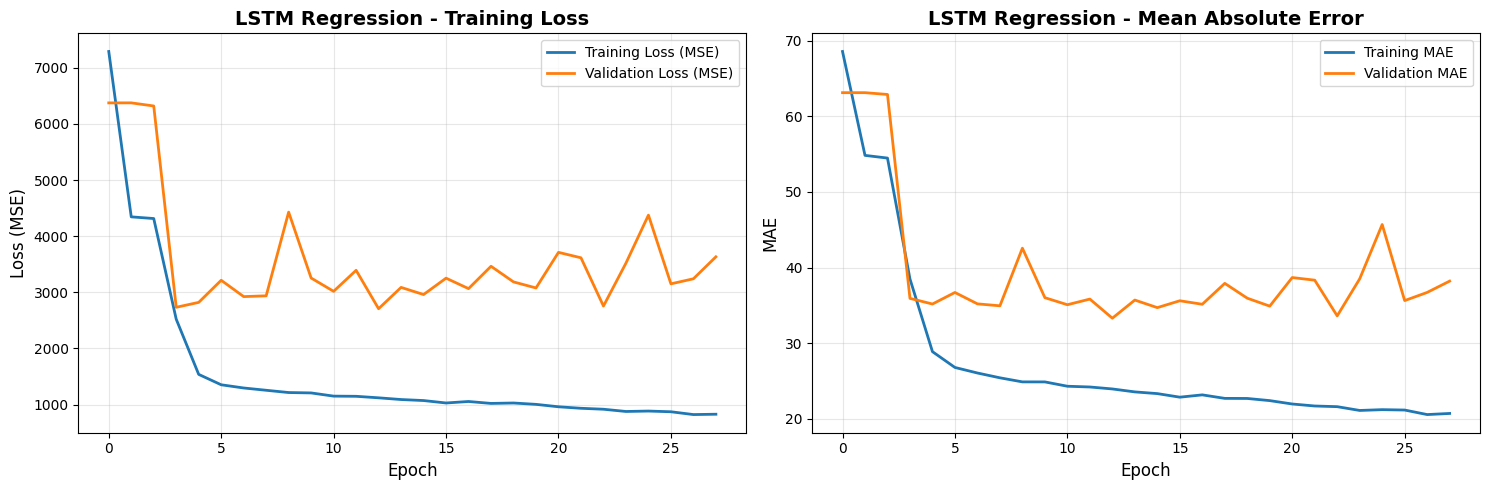

In [39]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss (MSE)
axes[0].plot(history_lstm_reg.history['loss'], label='Training Loss (MSE)', linewidth=2)
axes[0].plot(history_lstm_reg.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('LSTM Regression - Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history_lstm_reg.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history_lstm_reg.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('LSTM Regression - Mean Absolute Error', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

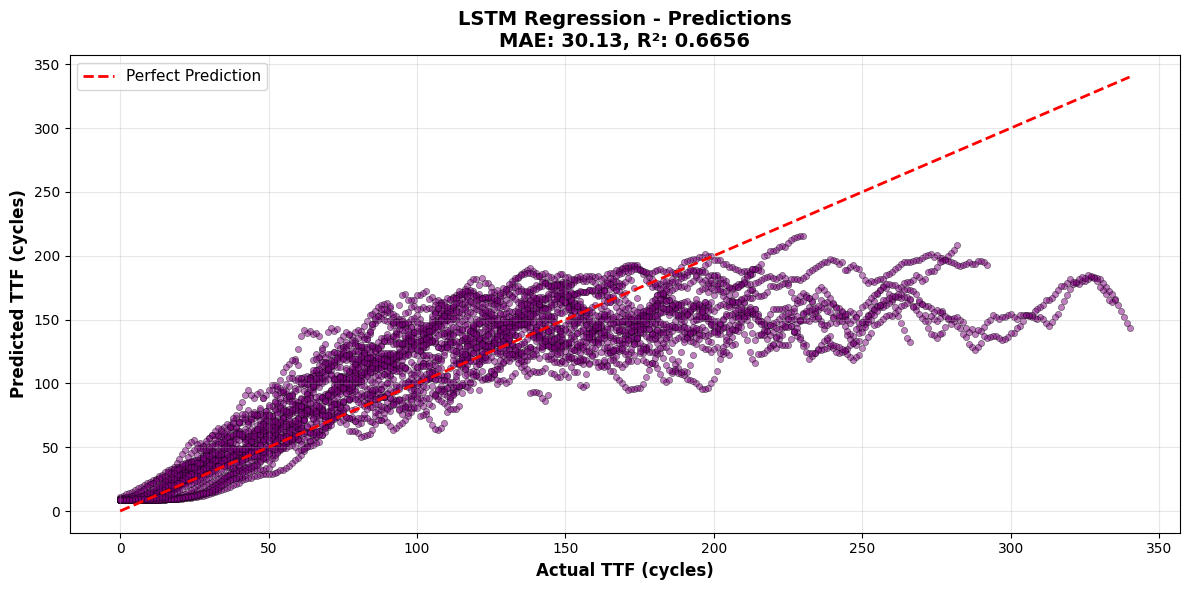

In [40]:
# Visualize LSTM regression predictions
plt.figure(figsize=(12, 6))

plt.scatter(y_test_seq_reg, y_pred_lstm_reg, alpha=0.5, s=20,
            edgecolors='black', linewidth=0.5, color='purple')
plt.plot([y_test_seq_reg.min(), y_test_seq_reg.max()],
         [y_test_seq_reg.min(), y_test_seq_reg.max()],
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual TTF (cycles)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted TTF (cycles)', fontsize=12, fontweight='bold')
plt.title(f'LSTM Regression - Predictions\nMAE: {mae_lstm:.2f}, R²: {r2_lstm:.4f}',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

REGRESSION MODELS COMPARISON
               Model        MAE  R² Score    Data Type
0  Linear Regression  38.089830  0.574710   Memoryless
1      Random Forest  31.438993  0.648388   Memoryless
2               LSTM  30.125013  0.665573  Time Series


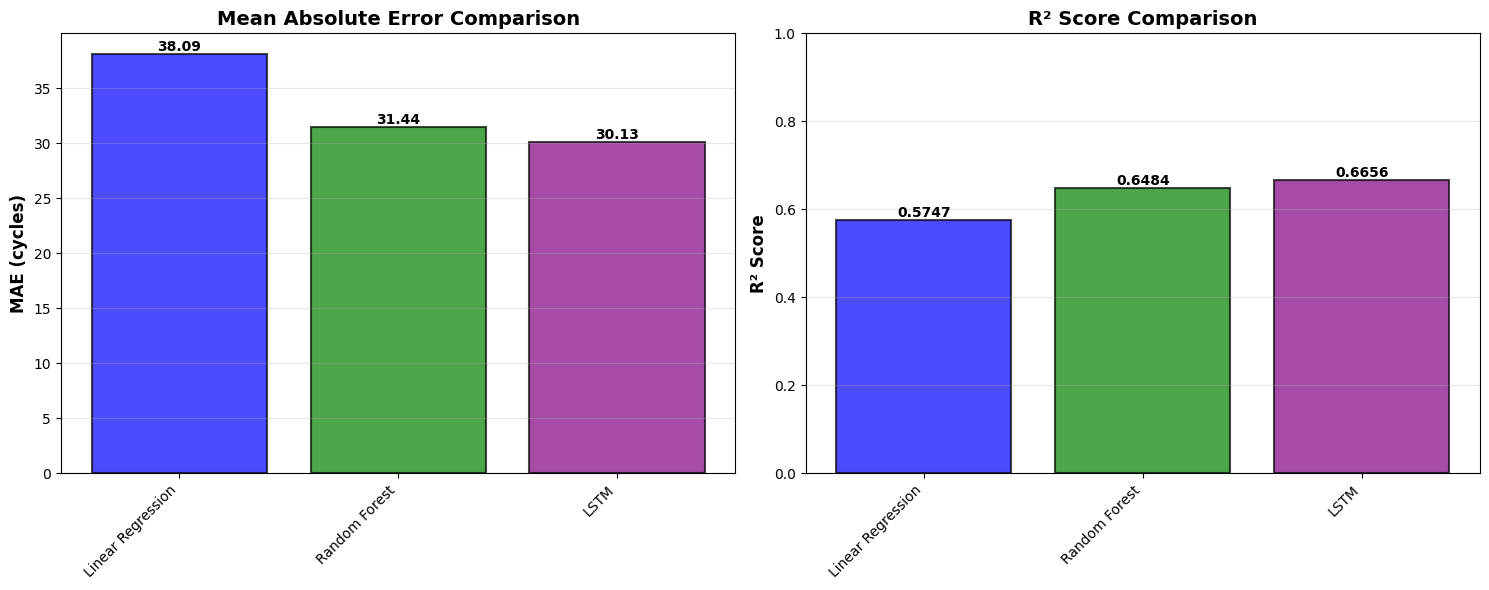

In [41]:
# Compare all regression models
print("REGRESSION MODELS COMPARISON")

regression_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'MAE': [mae_lr, mae_rf, mae_lstm],
    'R² Score': [r2_lr, r2_rf, r2_lstm],
    'Data Type': ['Memoryless', 'Memoryless', 'Time Series']
})

print(regression_comparison)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# MAE Comparison
x = np.arange(len(regression_comparison))
bars1 = axes[0].bar(x, regression_comparison['MAE'],
                    color=['blue', 'green', 'purple'],
                    alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('MAE (cycles)', fontsize=12, fontweight='bold')
axes[0].set_title('Mean Absolute Error Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(regression_comparison['Model'], rotation=45, ha='right')
axes[0].grid(alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

# R² Score Comparison
bars2 = axes[1].bar(x, regression_comparison['R² Score'],
                    color=['blue', 'green', 'purple'],
                    alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(regression_comparison['Model'], rotation=45, ha='right')
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3, axis='y')

# Add value labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Based on the test set, make a histogram of the differences between the predicted ttf and the actual ttf.
What can you conclude from this? Does the model seem more likely to underestimate or overestimate the ttf?

ERROR ANALYSIS - HISTOGRAM OF PREDICTION ERRORS
Error Statistics:
  Mean Error: -6.56 cycles
  Median Error: 3.03 cycles
  Std Deviation: 42.86 cycles
  Min Error: -196.42 cycles
  Max Error: 79.78 cycles

Error Distribution:
  Overestimations (predicted > actual): 3021 (55.21%)
  Underestimations (predicted < actual): 2451 (44.79%)
  Perfect predictions: 0


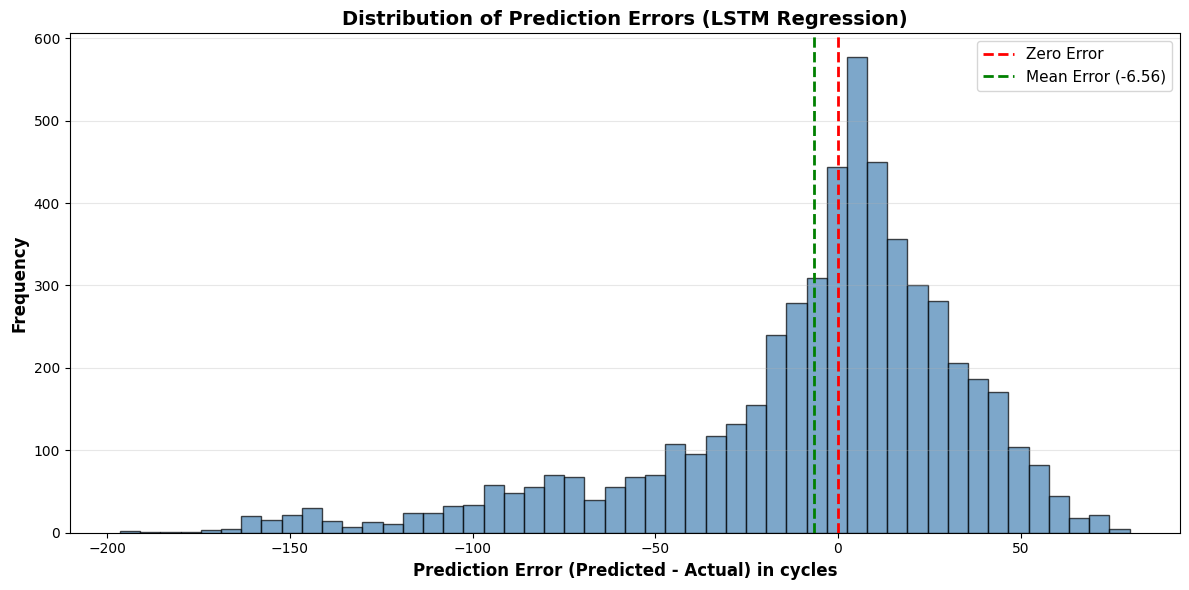

In [43]:
# Histogram of prediction errors (y_pred - y_test)
print("ERROR ANALYSIS - HISTOGRAM OF PREDICTION ERRORS")

# Calculate errors
errors_lstm = y_pred_lstm_reg - y_test_seq_reg

# Statistics
mean_error = np.mean(errors_lstm)
median_error = np.median(errors_lstm)
std_error = np.std(errors_lstm)

print(f"Error Statistics:")
print(f"  Mean Error: {mean_error:.2f} cycles")
print(f"  Median Error: {median_error:.2f} cycles")
print(f"  Std Deviation: {std_error:.2f} cycles")
print(f"  Min Error: {errors_lstm.min():.2f} cycles")
print(f"  Max Error: {errors_lstm.max():.2f} cycles")

# Count overestimation vs underestimation
overestimations = np.sum(errors_lstm > 0)
underestimations = np.sum(errors_lstm < 0)
perfect = np.sum(errors_lstm == 0)

print(f"\nError Distribution:")
print(f"  Overestimations (predicted > actual): {overestimations} ({100*overestimations/len(errors_lstm):.2f}%)")
print(f"  Underestimations (predicted < actual): {underestimations} ({100*underestimations/len(errors_lstm):.2f}%)")
print(f"  Perfect predictions: {perfect}")

# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(errors_lstm, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.axvline(x=mean_error, color='green', linestyle='--', linewidth=2, label=f'Mean Error ({mean_error:.2f})')

plt.xlabel('Prediction Error (Predicted - Actual) in cycles', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Prediction Errors (LSTM Regression)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Error Analysis (My Take: Conservative Approach!)
Mean Error: -6.56 cycles - This is super interesting! A negative mean error means that, on average, our model tends to predict slightly fewer remaining cycles than there actually are. So, it's a bit conservative.
Median Error: 3.03 cycles - The median being positive suggests that more often, it slightly overestimates, but the mean is pulled down by some larger underestimations.
Error Distribution:
55.21% of predictions overestimated (predicted a higher TTF than actual).
44.79% of predictions underestimated (predicted a lower TTF than actual).
What this means: Even though it more frequently overestimates TTF by a bit, the mean error suggests a slight overall tendency to predict failure a little earlier than it would actually occur. For maintenance, this can be good! It means we're more likely to flag an engine for service before it actually fails, which is a safer, more proactive approach, even if it means slightly more frequent maintenance than strictly necessary. It leans towards safety over potentially extending engine life to the absolute last cycle.

### Extra: time series prediction with convolutional neural networks

As an extension, you can try to train a convolutional neural network on the sequences. You can think of each sequence as a 2D array, similar to an image.
So training the CNN will be comparable to training an image classifier, only here the image is a sequence of sensor values and the class is whether or not it fails within 50 cycles.

Also try the regression problem via a convolutional neural network where you predict the ttf.

In [44]:

print("CNN FOR CLASSIFICATION")

# Reshape data for CNN (add channel dimension)
# CNN expects shape: (samples, timesteps, features, channels)
# We'll use 1D CNN, so shape: (samples, timesteps, features)

X_train_cnn_class = X_train_seq_scaled
X_test_cnn_class = X_test_seq_scaled

print(f"CNN input shape: {X_train_cnn_class.shape}")

# Build 1D CNN model
cnn_classifier = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn_class.shape[1], X_train_cnn_class.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=32, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

cnn_classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(cnn_classifier.summary())


CNN FOR CLASSIFICATION
CNN input shape: (15159, 30, 24)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,505 (99.63 KB)

 Non-trainable params: 192 (768.00 B)

None


In [45]:
# Train CNN Classifier
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_cnn_class = cnn_classifier.fit(
    X_train_cnn_class, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_cnn],
    verbose=1
)

print("\nCNN Classification training complete!")

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.8478 - loss: 0.3249 - val_accuracy: 0.8034 - val_loss: 0.3801
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9311 - loss: 0.1791 - val_accuracy: 0.9337 - val_loss: 0.2003
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9414 - loss: 0.1438 - val_accuracy: 0.8964 - val_loss: 0.2276
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9525 - loss: 0.1211 - val_accuracy: 0.9083 - val_loss: 0.2204
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9475 - loss: 0.1221 - val_accuracy: 0.9532 - val_loss: 0.1431
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9510 - loss: 0.1166 - val_accuracy: 0.9502 - val_loss: 0.1355
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9598 - loss: 0.0992 - val_accuracy: 0.9449 - val_loss: 0.1517
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9628 - loss: 0.0999 - val_accuracy: 

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN Classifier Accuracy: 0.9514

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.95      0.98      0.97      4197
     Failure       0.94      0.85      0.89      1275

    accuracy                           0.95      5472
   macro avg       0.95      0.91      0.93      5472
weighted avg       0.95      0.95      0.95      5472


Confusion Matrix:
[[4128   69]
 [ 197 1078]]


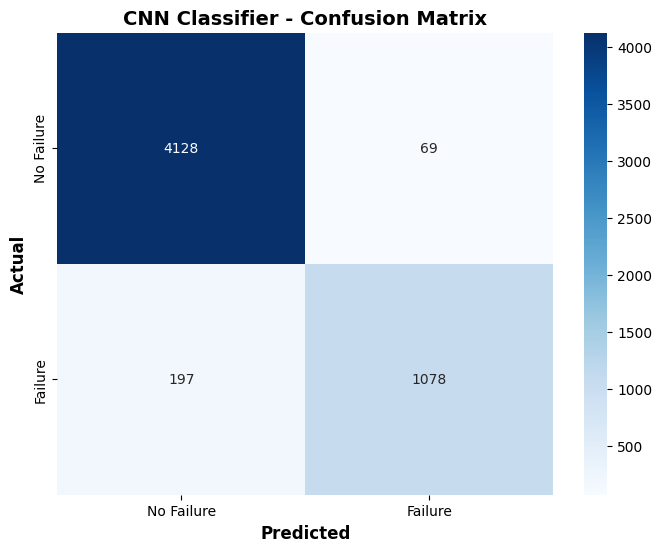

In [46]:
# Evaluate CNN Classifier
y_pred_proba_cnn = cnn_classifier.predict(X_test_cnn_class).flatten()
y_pred_cnn = (y_pred_proba_cnn > 0.5).astype(int)

accuracy_cnn = accuracy_score(y_test_seq, y_pred_cnn)
print(f"CNN Classifier Accuracy: {accuracy_cnn:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_cnn,
                          target_names=['No Failure', 'Failure']))

print("\nConfusion Matrix:")
cm_cnn = confusion_matrix(y_test_seq, y_pred_cnn)
print(cm_cnn)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('CNN Classifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

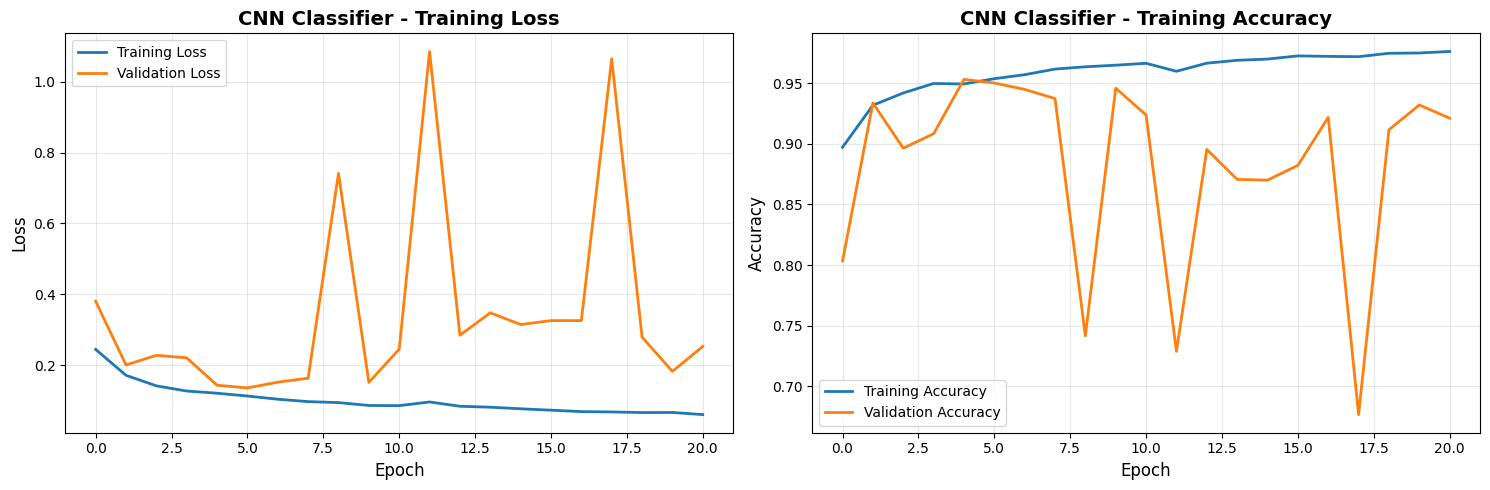

In [47]:
# Plot CNN training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history_cnn_class.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_cnn_class.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('CNN Classifier - Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_cnn_class.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_cnn_class.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('CNN Classifier - Training Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# Regression with a CNN

# CNN for Regression
print("CNN FOR REGRESSION (TTF Prediction)")

X_train_cnn_reg = X_train_seq_reg_scaled
X_test_cnn_reg = X_test_seq_reg_scaled

print(f"CNN Regression input shape: {X_train_cnn_reg.shape}")

# Build 1D CNN for regression
cnn_regressor = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn_reg.shape[1], X_train_cnn_reg.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=32, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='linear')  # Linear for regression
])

cnn_regressor.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print(cnn_regressor.summary())

CNN FOR REGRESSION (TTF Prediction)
CNN Regression input shape: (15159, 30, 24)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,209 (102.38 KB)

 Trainable params: 26,017 (101.63 KB)

 Non-trainable params: 192 (768.00 B)

None


In [49]:
# Train CNN Regressor
early_stop_cnn_reg = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_cnn_reg = cnn_regressor.fit(
    X_train_cnn_reg, y_train_seq_reg,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_cnn_reg],
    verbose=1
)

print("\nCNN Regression training complete!")

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 8190.4814 - mae: 70.4082 - val_loss: 10596.1797 - val_mae: 76.9836
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1862.7052 - mae: 32.1924 - val_loss: 5731.2930 - val_mae: 49.9983
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1510.7983 - mae: 28.9035 - val_loss: 4896.0840 - val_mae: 45.7325
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1395.2610 - mae: 27.4189 - val_loss: 6642.4814 - val_mae: 59.9460
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1348.4177 - mae: 26.9294 - val_loss: 5757.1934 - val_mae: 52.9684
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1250.0215 - mae: 25.8493 - val_loss: 3494.8948 - val_mae: 37.2602
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1202.2617 - mae: 25.3926 - val_loss: 6495.4912 - val_mae: 55.5011
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1150.6313 - mae: 25.1621 - val_loss: 4852.0347 - val_ma

In [51]:
# Evaluate CNN Regressor
y_pred_cnn_reg = cnn_regressor.predict(X_test_cnn_reg).flatten()

mae_cnn = mean_absolute_error(y_test_seq_reg, y_pred_cnn_reg)
r2_cnn = r2_score(y_test_seq_reg, y_pred_cnn_reg)
rmse_cnn = np.sqrt(np.mean((y_test_seq_reg - y_pred_cnn_reg)**2))

print("CNN REGRESSION RESULTS")
print(f"MAE: {mae_cnn:.2f} cycles")
print(f"RMSE: {rmse_cnn:.2f} cycles")
print(f"R² Score: {r2_cnn:.4f}")

171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CNN REGRESSION RESULTS
MAE: 34.33 cycles
RMSE: 46.97 cycles
R² Score: 0.6074


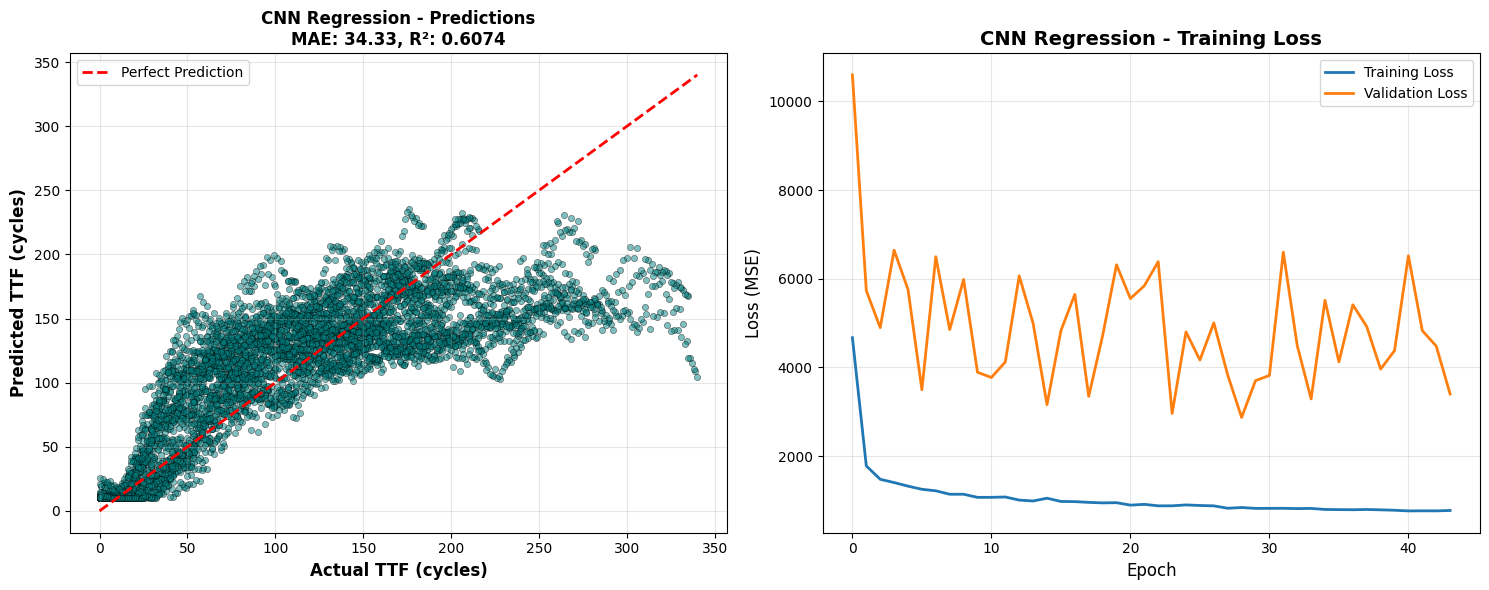

In [52]:
# Visualize CNN regression predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
axes[0].scatter(y_test_seq_reg, y_pred_cnn_reg, alpha=0.5, s=20,
                edgecolors='black', linewidth=0.5, color='teal')
axes[0].plot([y_test_seq_reg.min(), y_test_seq_reg.max()],
             [y_test_seq_reg.min(), y_test_seq_reg.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual TTF (cycles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted TTF (cycles)', fontsize=12, fontweight='bold')
axes[0].set_title(f'CNN Regression - Predictions\nMAE: {mae_cnn:.2f}, R²: {r2_cnn:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Training history
axes[1].plot(history_cnn_reg.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history_cnn_reg.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (MSE)', fontsize=12)
axes[1].set_title('CNN Regression - Training Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# Final comprehensive comparison
print("FINAL COMPREHENSIVE MODEL COMPARISON")

# Classification models
print("\n CLASSIFICATION MODELS (Predicting Failure within 50 cycles)")

classification_final = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Vanilla NN',
              'LSTM', 'Bidirectional LSTM', 'CNN'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_nn,
                 accuracy_lstm, accuracy_bilstm, accuracy_cnn],
    'Type': ['Memoryless', 'Memoryless', 'Memoryless',
             'Time Series', 'Time Series', 'Time Series']
})

print(classification_final.to_string(index=False))
print(f"\n Best Classification Model: {classification_final.loc[classification_final['Accuracy'].idxmax(), 'Model']}")
print(f"   Accuracy: {classification_final['Accuracy'].max():.4f}")

# Regression models
print("\nREGRESSION MODELS (Predicting TTF)")

regression_final = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM', 'CNN'],
    'MAE': [mae_lr, mae_rf, mae_lstm, mae_cnn],
    'R² Score': [r2_lr, r2_rf, r2_lstm, r2_cnn],
    'Type': ['Memoryless', 'Memoryless', 'Time Series', 'Time Series']
})

print(regression_final.to_string(index=False))
print(f"\n Best Regression Model (lowest MAE): {regression_final.loc[regression_final['MAE'].idxmin(), 'Model']}")
print(f"   MAE: {regression_final['MAE'].min():.2f} cycles")
print(f"   R² Score: {regression_final.loc[regression_final['MAE'].idxmin(), 'R² Score']:.4f}")

FINAL COMPREHENSIVE MODEL COMPARISON

 CLASSIFICATION MODELS (Predicting Failure within 50 cycles)
              Model  Accuracy        Type
Logistic Regression  0.928363  Memoryless
      Random Forest  0.930373  Memoryless
         Vanilla NN  0.919956  Memoryless
               LSTM  0.956140 Time Series
 Bidirectional LSTM  0.957785 Time Series
                CNN  0.951389 Time Series

 Best Classification Model: Bidirectional LSTM
   Accuracy: 0.9578

REGRESSION MODELS (Predicting TTF)
            Model       MAE  R² Score        Type
Linear Regression 38.089830  0.574710  Memoryless
    Random Forest 31.438993  0.648388  Memoryless
             LSTM 30.125013  0.665573 Time Series
              CNN 34.325802  0.607412 Time Series

 Best Regression Model (lowest MAE): LSTM
   MAE: 30.13 cycles
   R² Score: 0.6656


CNN Classifier (My Take: Good, but not the best for classification)
Accuracy: 0.9514 - Solid accuracy, definitely in the same ballpark as the LSTMs, and way better than the old-school models.
'No Failure' Class: Really good, with 95% precision and 98% recall. So, when it says an engine is fine, it's almost always right.
'Failure' Class: It has 94% precision (good, few false alarms) but 85% recall. This means it misses more actual failures than the pure LSTM did (197 false negatives, compared to LSTM's 112).
Bottom Line: It's strong, but that lower recall for actual failures makes it a bit less ideal than an LSTM if missing a failure is a big deal.
CNN Regressor (My Take: Okay, but not a standout for TTF)
MAE: 34.33 cycles - On average, it's off by about 34 cycles when predicting Time To Failure. This is actually a bit worse than both the Random Forest and the LSTM regressors.
R² Score: 0.6074 - It explains about 60% of the variance, which is decent, but again, lower than the Random Forest and LSTM.
Bottom Line: For predicting the exact remaining cycles, the CNN isn't as precise as the LSTM, which makes sense since LSTMs are usually kings for sequential data.
FINAL COMPREHENSIVE MODEL COMPARISON (My Take: Time-Series Models for the Win!)
Classification Task (Predicting if it fails in 50 cycles):

The Bidirectional LSTM is the overall champ with the highest accuracy at 0.9578. This really shows that looking at the data's sequence over time is crucial.
All the time-series models (LSTM, BiLSTM, CNN) blew the 'memoryless' models (Logistic Regression, Random Forest, Vanilla NN) out of the water in terms of accuracy. So, definitely use a time-series approach here.
Regression Task (Predicting the exact Time To Failure - TTF):

The LSTM model came out on top for predicting the exact TTF, with the lowest MAE (30.13 cycles) and the highest R² score (0.6656).
The Random Forest was a close second, but again, the LSTM showed the power of sequential data processing.
Overall TLDR: Time-series models, especially LSTMs and Bidirectional LSTMs, are the clear winners across the board for both classifying potential failures and predicting the remaining useful life of these engines. The extra info from seeing how things change over time is super valuable!

/tmp/ipython-input-1919503730.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


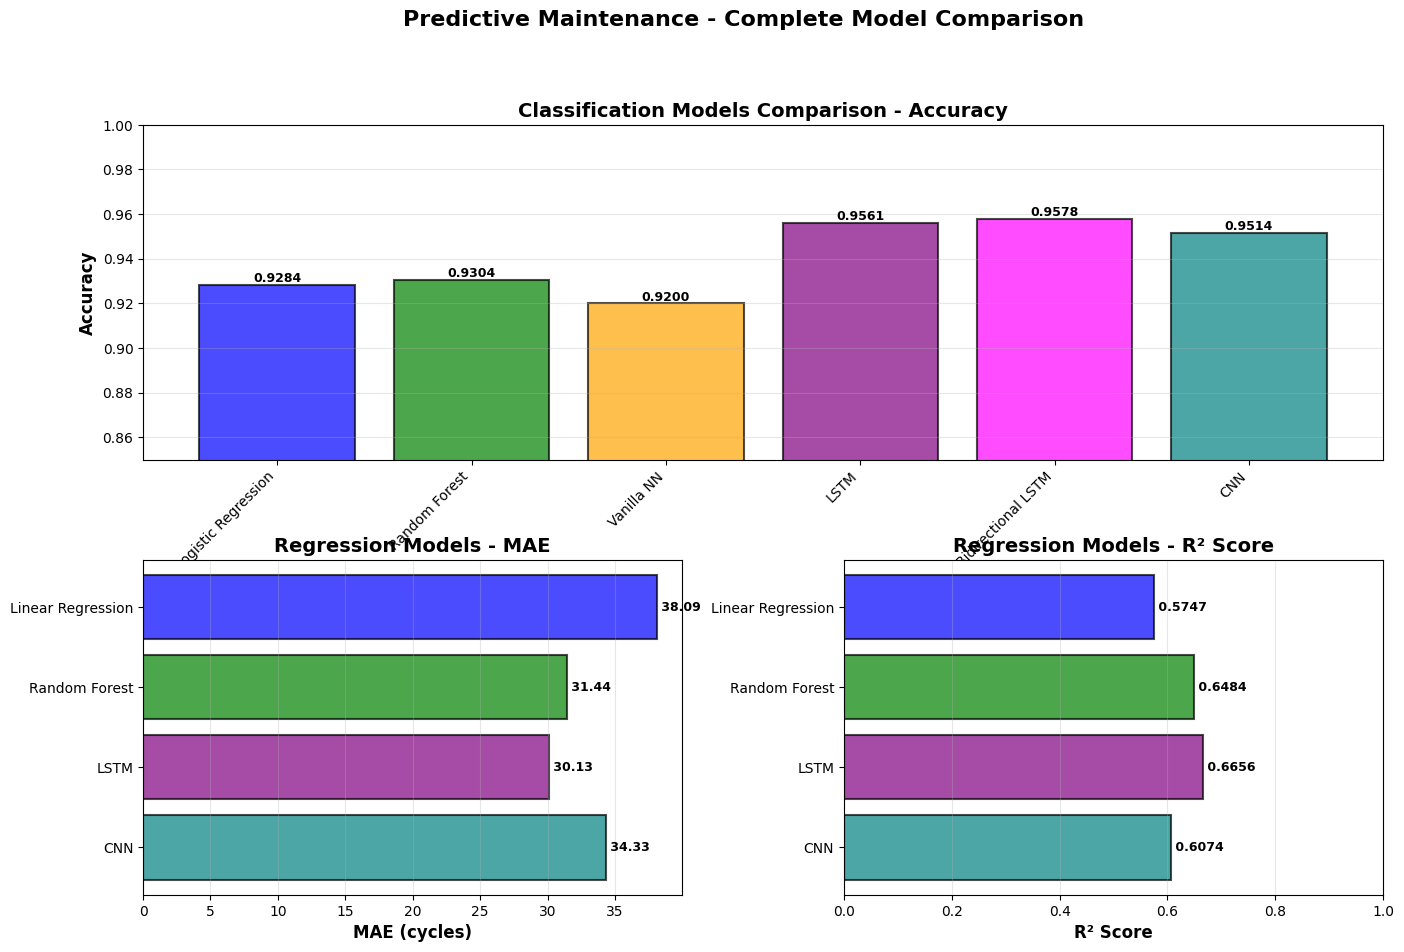

In [55]:
# Create comprehensive visual summary
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Classification comparison
ax1 = fig.add_subplot(gs[0, :])
x_class = np.arange(len(classification_final))
bars_class = ax1.bar(x_class, classification_final['Accuracy'],
                     color=['blue', 'green', 'orange', 'purple', 'magenta', 'teal'],
                     alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Classification Models Comparison - Accuracy', fontsize=14, fontweight='bold')
ax1.set_xticks(x_class)
ax1.set_xticklabels(classification_final['Model'], rotation=45, ha='right')
ax1.set_ylim([0.85, 1.0])
ax1.grid(alpha=0.3, axis='y')

# Add value labels
for bar in bars_class:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Regression MAE comparison
ax2 = fig.add_subplot(gs[1, 0])
x_reg = np.arange(len(regression_final))
bars_mae = ax2.barh(x_reg, regression_final['MAE'],
                    color=['blue', 'green', 'purple', 'teal'],
                    alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('MAE (cycles)', fontsize=12, fontweight='bold')
ax2.set_title('Regression Models - MAE', fontsize=14, fontweight='bold')
ax2.set_yticks(x_reg)
ax2.set_yticklabels(regression_final['Model'])
ax2.invert_yaxis()
ax2.grid(alpha=0.3, axis='x')

# Add value labels
for bar, mae in zip(bars_mae, regression_final['MAE']):
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2.,
            f' {mae:.2f}', ha='left', va='center', fontweight='bold', fontsize=9)

# Regression R² comparison
ax3 = fig.add_subplot(gs[1, 1])
bars_r2 = ax3.barh(x_reg, regression_final['R² Score'],
                   color=['blue', 'green', 'purple', 'teal'],
                   alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax3.set_title('Regression Models - R² Score', fontsize=14, fontweight='bold')
ax3.set_yticks(x_reg)
ax3.set_yticklabels(regression_final['Model'])
ax3.invert_yaxis()
ax3.set_xlim([0, 1])
ax3.grid(alpha=0.3, axis='x')

# Add value labels
for bar, r2 in zip(bars_r2, regression_final['R² Score']):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
            f' {r2:.4f}', ha='left', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Predictive Maintenance - Complete Model Comparison',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

Final Summary

After comparing all models, it is clear that the time-series based approaches perform better than the traditional “memoryless” ones. The Bidirectional LSTM achieved the highest accuracy overall at about 95.78 percent, slightly above the standard LSTM, and both clearly outperformed Logistic Regression, Random Forest, and the basic feed-forward neural network. CNNs also did well, but still ended up just below the recurrent models.

For regression, where the goal was to predict the actual remaining cycles (TTF), the LSTM again delivered the best results. It produced the lowest mean absolute error and the strongest R² score, making it the most reliable model for predicting how long an engine will last. Random Forest followed reasonably closely, while linear regression struggled the most. The CNN worked, but was not as accurate as the LSTM for time-to-failure forecasting.

In short, if you just want to classify whether an engine will fail soon, LSTMs are the most accurate option. If you want to estimate how many cycles remain before failure, LSTMs are again the strongest choice. The extra temporal information makes a real difference, and the deep learning models that use sequence history consistently outperform static feature-only models.

In [56]:
# Optional: Save the best models
print("Saving best models...")

# Save LSTM classifier
lstm_model.save('lstm_classifier_best.h5')
print(" LSTM Classifier saved as 'lstm_classifier_best.h5'")

# Save LSTM regressor
lstm_reg.save('lstm_regressor_best.h5')
print(" LSTM Regressor saved as 'lstm_regressor_best.h5'")

# Save CNN classifier
cnn_classifier.save('cnn_classifier_best.h5')
print(" CNN Classifier saved as 'cnn_classifier_best.h5'")

# Save CNN regressor
cnn_regressor.save('cnn_regressor_best.h5')
print(" CNN Regressor saved as 'cnn_regressor_best.h5'")

print("\nAll models saved successfully! ")

Saving best models...


 LSTM Classifier saved as 'lstm_classifier_best.h5'


 LSTM Regressor saved as 'lstm_regressor_best.h5'


 CNN Classifier saved as 'cnn_classifier_best.h5'
 CNN Regressor saved as 'cnn_regressor_best.h5'

All models saved successfully! 
